# Pearls AQI Predictor — EDA & Model Training

This notebook covers the exploratory data analysis and model training pipeline for forecasting Karachi's US AQI at 24h, 48h, and 72h horizons, as part of the Pearls AQI Predictor project (a serverless MLOps stack).

**Data source**: hourly weather and pollutant data ingested and stored via a Hopsworks feature store, backfilled and kept up to date through an automated GitHub Actions pipeline. This notebook uses a snapshot of that data through 2026-08-22.

**What this notebook covers**:
1. Data loading, cleaning, and missing-row interpolation
2. Exploratory Data Analysis — univariate distributions, temporal patterns, correlation analysis, pair plots, ACF/PACF, stationarity testing, and horizon-wise correlation decay
3. Feature engineering — lag features, rolling statistics, and cyclic encoding of time-based and directional features
4. Model training and evaluation — Ridge Regression, Random Forest, and a Neural Network, each trained separately per forecast horizon
5. Model comparison against a naive persistence baseline
6. SHAP-based feature importance analysis
7. Final model selection and registration to the Hopsworks Model Registry

**Final model selected**: Random Forest — the most consistent performer across all three horizons and the strongest improvement over the persistence baseline (see Final Model Selection section for the full comparison).

In [1]:
# !pip install hopsworks["python"]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import hopsworks
from google.colab import userdata

In [2]:
# api_key = userdata.get("HOPSWORKS_API_KEY")

In [3]:
# project = hopsworks.login(
#         project='PearlsAQI_Project',
#         host="eu-west.cloud.hopsworks.ai",
#         port=443,
#         api_key_value=api_key,
# )

# fs = project.get_feature_store()
# fg = fs.get_feature_group(name="karachi_aqi",version=1)

In [4]:
# df = fg.read()
# df

- `ammonia` column doesn't have any value so dropping it.

In [5]:
# df.drop("ammonia",axis=1,inplace=True)

- saving the file because we are going to use data till 2026-08-22 21:00:00 for EDA and initial model training.

In [6]:
# df.to_csv(f"AQI_data_till_{df["timestamp"].max()}.csv")

In [7]:
aqi = pd.read_csv("https://raw.githubusercontent.com/SyedAnasAzim/AQI-prediction/main/Notebook/AQI_data_till_2026-08-22%2021_00_00.csv")
aqi

,Unnamed: 0,timestamp,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,city
0,0,2026-08-22 20:00:00,17.3,38.0,250.0,11.5,4.5,42.0,29.0,68,27.1,85,16.5,232,1001.6,0.0,19,Karachi
1,1,2026-08-22 18:00:00,20.4,47.3,256.0,9.1,4.4,47.0,35.0,68,27.9,79,18.8,230,1000.6,0.0,80,Karachi
2,2,2026-08-22 11:00:00,23.5,63.8,184.0,4.4,4.5,60.0,64.0,67,29.6,70,19.6,252,1003.4,0.0,100,Karachi
3,3,2026-08-22 10:00:00,23.3,63.8,205.0,6.0,4.6,54.0,58.0,66,29.3,69,20.6,256,1004.5,0.0,100,Karachi
4,4,2026-08-22 09:00:00,21.8,58.7,234.0,7.9,4.7,47.0,50.0,66,28.9,70,20.2,254,1004.6,0.0,97,Karachi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18039,18039,2026-08-21 18:00:00,18.4,46.1,243.0,9.1,4.7,47.0,49.0,63,28.0,81,16.9,237,1001.6,0.2,93,Karachi
18040,18040,2026-08-21 19:00:00,18.3,41.8,235.0,11.2,4.7,43.0,48.0,63,27.3,86,17.2,237,1001.9,0.1,94,Karachi
18041,18041,2026-08-21 20:00:00,20.7,51.0,225.0,12.4,4.8,41.0,45.0,63,27.2,86,17.5,235,1002.5,0.3,100,Karachi
18042,18042,2026-08-21 21:00:00,17.7,43.8,215.0,12.2,4.8,40.0,40.0,64,27.2,86,17.9,236,1003.0,0.2,100,Karachi


In [8]:
df = aqi.copy()
df.head()

,Unnamed: 0,timestamp,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,city
0,0,2026-08-22 20:00:00,17.3,38.0,250.0,11.5,4.5,42.0,29.0,68,27.1,85,16.5,232,1001.6,0.0,19,Karachi
1,1,2026-08-22 18:00:00,20.4,47.3,256.0,9.1,4.4,47.0,35.0,68,27.9,79,18.8,230,1000.6,0.0,80,Karachi
2,2,2026-08-22 11:00:00,23.5,63.8,184.0,4.4,4.5,60.0,64.0,67,29.6,70,19.6,252,1003.4,0.0,100,Karachi
3,3,2026-08-22 10:00:00,23.3,63.8,205.0,6.0,4.6,54.0,58.0,66,29.3,69,20.6,256,1004.5,0.0,100,Karachi
4,4,2026-08-22 09:00:00,21.8,58.7,234.0,7.9,4.7,47.0,50.0,66,28.9,70,20.2,254,1004.6,0.0,97,Karachi


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18044 entries, 0 to 18043
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            18044 non-null  int64  
 1   timestamp             18044 non-null  object 
 2   pm2_5                 18044 non-null  float64
 3   pm10                  18044 non-null  float64
 4   carbon_monoxide       18044 non-null  float64
 5   nitrogen_dioxide      18044 non-null  float64
 6   sulphur_dioxide       18044 non-null  float64
 7   ozone                 18044 non-null  float64
 8   dust                  18044 non-null  float64
 9   us_aqi                18044 non-null  int64  
 10  temperature_2m        18044 non-null  float64
 11  relative_humidity_2m  18044 non-null  int64  
 12  wind_speed_10m        18044 non-null  float64
 13  wind_direction_10m    18044 non-null  int64  
 14  surface_pressure      18044 non-null  float64
 15  precipitation      

In [10]:
df.head()

,Unnamed: 0,timestamp,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,city
0,0,2026-08-22 20:00:00,17.3,38.0,250.0,11.5,4.5,42.0,29.0,68,27.1,85,16.5,232,1001.6,0.0,19,Karachi
1,1,2026-08-22 18:00:00,20.4,47.3,256.0,9.1,4.4,47.0,35.0,68,27.9,79,18.8,230,1000.6,0.0,80,Karachi
2,2,2026-08-22 11:00:00,23.5,63.8,184.0,4.4,4.5,60.0,64.0,67,29.6,70,19.6,252,1003.4,0.0,100,Karachi
3,3,2026-08-22 10:00:00,23.3,63.8,205.0,6.0,4.6,54.0,58.0,66,29.3,69,20.6,256,1004.5,0.0,100,Karachi
4,4,2026-08-22 09:00:00,21.8,58.7,234.0,7.9,4.7,47.0,50.0,66,28.9,70,20.2,254,1004.6,0.0,97,Karachi


#### Looking for duplicates and missing values

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isna().sum().sum()

np.int64(0)

- no duplicates and no missing values

#### Sorting the `timestamp` column

In [13]:
df["timestamp"] = df["timestamp"].sort_values()

In [14]:
df.tail(20)

,Unnamed: 0,timestamp,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,city
18024,18024,2026-08-21 03:00:00,11.9,25.0,112.0,6.4,4.3,38.0,16.0,62,26.7,85,12.6,253,1002.9,0.0,79,Karachi
18025,18025,2026-08-21 04:00:00,11.8,25.6,106.0,5.7,4.3,39.0,18.0,62,26.6,86,13.6,253,1002.8,0.0,78,Karachi
18026,18026,2026-08-21 05:00:00,11.8,25.8,120.0,5.6,4.4,40.0,20.0,62,26.8,85,14.0,258,1003.1,0.0,45,Karachi
18027,18027,2026-08-21 06:00:00,12.3,27.0,173.0,7.0,4.8,39.0,23.0,62,26.8,86,13.5,260,1003.6,0.0,91,Karachi
18028,18028,2026-08-21 07:00:00,14.2,31.3,244.0,8.8,5.3,38.0,28.0,62,27.1,84,12.8,261,1004.1,0.0,91,Karachi
18029,18029,2026-08-21 08:00:00,15.2,37.0,288.0,9.7,5.6,39.0,34.0,62,27.8,79,14.4,260,1004.5,0.0,98,Karachi
18030,18030,2026-08-21 09:00:00,19.7,53.0,275.0,8.7,5.6,45.0,41.0,62,28.7,74,15.7,253,1004.9,0.0,100,Karachi
18031,18031,2026-08-21 10:00:00,20.3,55.3,234.0,6.6,5.4,53.0,48.0,62,28.9,74,16.4,245,1004.9,0.1,100,Karachi
18032,18032,2026-08-21 11:00:00,20.5,54.2,201.0,5.0,5.2,59.0,53.0,62,29.6,70,17.8,242,1005.0,0.1,100,Karachi
18033,18033,2026-08-21 12:00:00,19.4,49.4,191.0,4.2,5.0,63.0,53.0,62,29.3,71,17.2,242,1004.5,0.1,100,Karachi


#### Looking for some missing rows

In [15]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

expected = pd.date_range(
    start=df["timestamp"].min(),
    end=df["timestamp"].max(),
    freq="h"
)

missing_rows = expected.difference(df["timestamp"])

print("Number of missing rows:", len(missing_rows))
print(missing_rows)

Number of missing rows: 2
DatetimeIndex(['2026-08-22 05:00:00', '2026-08-22 07:00:00'], dtype='datetime64[ns]', freq=None)


- some rows are missing because github does the schedule task of adding new rows very late due to which some hours are missing but the good thing is only one hour is missing in between not a series of hours so we can use time interpolation

In [16]:
df.set_index("timestamp",inplace=True)


In [17]:
df.drop("Unnamed: 0",axis=1,inplace=True)



In [18]:
full_index = pd.date_range(
    df.index.min(),
    df.index.max(),
    freq="h"
)
df = df.reindex(full_index)

In [19]:
df

,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,city
2024-08-01 00:00:00,20.5,46.8,217.0,14.6,4.6,43.0,42.0,66.0,28.7,88.0,23.3,235.0,998.9,0.0,62.0,Karachi
2024-08-01 01:00:00,18.9,46.0,180.0,10.5,4.0,45.0,47.0,66.0,28.6,88.0,22.4,240.0,998.3,0.0,94.0,Karachi
2024-08-01 02:00:00,17.9,46.4,152.0,7.4,3.6,47.0,51.0,66.0,28.6,87.0,22.6,245.0,997.9,0.0,82.0,Karachi
2024-08-01 03:00:00,17.2,47.1,136.0,5.8,3.4,48.0,53.0,66.0,28.7,85.0,23.9,249.0,997.6,0.0,100.0,Karachi
2024-08-01 04:00:00,16.9,47.1,128.0,5.1,3.5,48.0,53.0,66.0,28.6,85.0,24.4,254.0,997.9,0.0,96.0,Karachi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-22 17:00:00,20.3,47.7,250.0,7.6,4.3,50.0,39.0,68.0,28.3,76.0,18.2,231.0,1000.5,0.0,99.0,Karachi
2026-08-22 18:00:00,20.4,47.3,256.0,9.1,4.4,47.0,35.0,68.0,27.9,79.0,18.8,230.0,1000.6,0.0,80.0,Karachi
2026-08-22 19:00:00,20.2,44.6,255.0,10.6,4.4,44.0,31.0,68.0,27.3,83.0,18.1,230.0,1001.0,0.0,33.0,Karachi
2026-08-22 20:00:00,17.3,38.0,250.0,11.5,4.5,42.0,29.0,68.0,27.1,85.0,16.5,232.0,1001.6,0.0,19.0,Karachi


In [20]:
df.set_index(pd.to_datetime(df.index),inplace=True)
df = df.interpolate(method="time",limit=2)


/tmp/ipykernel_1131/3225721046.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method="time",limit=2)


In [21]:
df.sort_index().tail(20)

,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,city
2026-08-22 02:00:00,16.20,40.50,123.0,5.1,3.70,46.0,37.0,65.0,26.5,87.0,15.40,247.0,1002.70,0.0,100.0,Karachi
2026-08-22 03:00:00,13.50,30.20,114.0,5.3,3.90,44.0,24.0,66.0,26.5,88.0,16.10,248.0,1002.40,0.0,99.0,Karachi
2026-08-22 04:00:00,13.20,29.60,112.0,4.9,4.10,44.0,24.0,66.0,26.4,88.0,16.80,252.0,1002.20,0.0,100.0,Karachi
2026-08-22 05:00:00,13.25,30.15,137.0,5.6,4.25,43.0,27.0,66.0,26.5,86.5,15.55,254.0,1002.80,0.0,68.0,NaN
2026-08-22 06:00:00,13.30,30.70,162.0,6.3,4.40,42.0,30.0,66.0,26.6,85.0,14.30,256.0,1003.40,0.0,36.0,Karachi
2026-08-22 07:00:00,14.90,36.65,202.5,7.6,4.55,42.0,36.0,66.0,27.4,79.5,16.35,255.0,1003.85,0.0,59.5,NaN
2026-08-22 08:00:00,16.50,42.60,243.0,8.9,4.70,42.0,42.0,66.0,28.2,74.0,18.40,254.0,1004.30,0.0,83.0,Karachi
2026-08-22 09:00:00,21.80,58.70,234.0,7.9,4.70,47.0,50.0,66.0,28.9,70.0,20.20,254.0,1004.60,0.0,97.0,Karachi
2026-08-22 10:00:00,23.30,63.80,205.0,6.0,4.60,54.0,58.0,66.0,29.3,69.0,20.60,256.0,1004.50,0.0,100.0,Karachi
2026-08-22 11:00:00,23.50,63.80,184.0,4.4,4.50,60.0,64.0,67.0,29.6,70.0,19.60,252.0,1003.40,0.0,100.0,Karachi


In [22]:
df.isna().sum()

,0
pm2_5,0
pm10,0
carbon_monoxide,0
nitrogen_dioxide,0
sulphur_dioxide,0
ozone,0
dust,0
us_aqi,0
temperature_2m,0
relative_humidity_2m,0


there is NAN in the `city` column for missing rows that we interpolated so for now we are just going to make every value in city to Karachi beacuse we are just using the  karachi data for now.

In [23]:
df["city"] = "Karachi"

In [24]:
df.isna().sum()

,0
pm2_5,0
pm10,0
carbon_monoxide,0
nitrogen_dioxide,0
sulphur_dioxide,0
ozone,0
dust,0
us_aqi,0
temperature_2m,0
relative_humidity_2m,0


In [25]:
df.tail(20)

,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,city
2026-08-22 02:00:00,16.20,40.50,123.0,5.1,3.70,46.0,37.0,65.0,26.5,87.0,15.40,247.0,1002.70,0.0,100.0,Karachi
2026-08-22 03:00:00,13.50,30.20,114.0,5.3,3.90,44.0,24.0,66.0,26.5,88.0,16.10,248.0,1002.40,0.0,99.0,Karachi
2026-08-22 04:00:00,13.20,29.60,112.0,4.9,4.10,44.0,24.0,66.0,26.4,88.0,16.80,252.0,1002.20,0.0,100.0,Karachi
2026-08-22 05:00:00,13.25,30.15,137.0,5.6,4.25,43.0,27.0,66.0,26.5,86.5,15.55,254.0,1002.80,0.0,68.0,Karachi
2026-08-22 06:00:00,13.30,30.70,162.0,6.3,4.40,42.0,30.0,66.0,26.6,85.0,14.30,256.0,1003.40,0.0,36.0,Karachi
2026-08-22 07:00:00,14.90,36.65,202.5,7.6,4.55,42.0,36.0,66.0,27.4,79.5,16.35,255.0,1003.85,0.0,59.5,Karachi
2026-08-22 08:00:00,16.50,42.60,243.0,8.9,4.70,42.0,42.0,66.0,28.2,74.0,18.40,254.0,1004.30,0.0,83.0,Karachi
2026-08-22 09:00:00,21.80,58.70,234.0,7.9,4.70,47.0,50.0,66.0,28.9,70.0,20.20,254.0,1004.60,0.0,97.0,Karachi
2026-08-22 10:00:00,23.30,63.80,205.0,6.0,4.60,54.0,58.0,66.0,29.3,69.0,20.60,256.0,1004.50,0.0,100.0,Karachi
2026-08-22 11:00:00,23.50,63.80,184.0,4.4,4.50,60.0,64.0,67.0,29.6,70.0,19.60,252.0,1003.40,0.0,100.0,Karachi


In [26]:
df["month_name"] = df.index.month_name()
df["day"] = df.index.day
df["day_name"] = df.index.day_name()
df["hour"] = df.index.hour

In [27]:
df

,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,city,month_name,day,day_name,hour
2024-08-01 00:00:00,20.5,46.8,217.0,14.6,4.6,43.0,42.0,66.0,28.7,88.0,23.3,235.0,998.9,0.0,62.0,Karachi,August,1,Thursday,0
2024-08-01 01:00:00,18.9,46.0,180.0,10.5,4.0,45.0,47.0,66.0,28.6,88.0,22.4,240.0,998.3,0.0,94.0,Karachi,August,1,Thursday,1
2024-08-01 02:00:00,17.9,46.4,152.0,7.4,3.6,47.0,51.0,66.0,28.6,87.0,22.6,245.0,997.9,0.0,82.0,Karachi,August,1,Thursday,2
2024-08-01 03:00:00,17.2,47.1,136.0,5.8,3.4,48.0,53.0,66.0,28.7,85.0,23.9,249.0,997.6,0.0,100.0,Karachi,August,1,Thursday,3
2024-08-01 04:00:00,16.9,47.1,128.0,5.1,3.5,48.0,53.0,66.0,28.6,85.0,24.4,254.0,997.9,0.0,96.0,Karachi,August,1,Thursday,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-22 17:00:00,20.3,47.7,250.0,7.6,4.3,50.0,39.0,68.0,28.3,76.0,18.2,231.0,1000.5,0.0,99.0,Karachi,August,22,Saturday,17
2026-08-22 18:00:00,20.4,47.3,256.0,9.1,4.4,47.0,35.0,68.0,27.9,79.0,18.8,230.0,1000.6,0.0,80.0,Karachi,August,22,Saturday,18
2026-08-22 19:00:00,20.2,44.6,255.0,10.6,4.4,44.0,31.0,68.0,27.3,83.0,18.1,230.0,1001.0,0.0,33.0,Karachi,August,22,Saturday,19
2026-08-22 20:00:00,17.3,38.0,250.0,11.5,4.5,42.0,29.0,68.0,27.1,85.0,16.5,232.0,1001.6,0.0,19.0,Karachi,August,22,Saturday,20


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 18046 entries, 2024-08-01 00:00:00 to 2026-08-22 21:00:00
Freq: h
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pm2_5                 18046 non-null  float64
 1   pm10                  18046 non-null  float64
 2   carbon_monoxide       18046 non-null  float64
 3   nitrogen_dioxide      18046 non-null  float64
 4   sulphur_dioxide       18046 non-null  float64
 5   ozone                 18046 non-null  float64
 6   dust                  18046 non-null  float64
 7   us_aqi                18046 non-null  float64
 8   temperature_2m        18046 non-null  float64
 9   relative_humidity_2m  18046 non-null  float64
 10  wind_speed_10m        18046 non-null  float64
 11  wind_direction_10m    18046 non-null  float64
 12  surface_pressure      18046 non-null  float64
 13  precipitation         18046 non-null  float64
 14  cloud_cover           18046

In [29]:
def plot_distribution_profile(data, column_name):
    """Plots a histogram with KDE and prints detailed skewness metrics."""
    # 1. Calculate statistical metrics
    skewness = data[column_name].skew()
    mean_val = data[column_name].mean()
    median_val = data[column_name].median()

    # Determine skewness type
    if skewness > 0.5:
        skew_type = "Positively Skewed (Right-tailed)"
    elif skewness < -0.5:
        skew_type = "Negatively Skewed (Left-tailed)"
    else:
        skew_type = "Approximately Symmetric"

    # 2. Print detailed text analysis
    print("=" * 45)
    print(f"      DISTRIBUTION PROFILE: {column_name.upper()}      ")
    print("=" * 45)
    print(f"Skewness Score : {skewness:.4f}")
    print(f"Skewness Type  : {skew_type}")
    print("-" * 45)
    print(f"Mean Value     : {mean_val:.2f}")
    print(f"Median Value   : {median_val:.2f}")
    print(f"Difference     : {abs(mean_val - median_val):.2f}")
    print("=" * 45)

    # 3. Create the visualization
    plt.figure(figsize=(10, 6))

    # Plot histogram + KDE curve
    sns.histplot(
        data=data, x=column_name, kde=True, color="skyblue", stat="density"
    )

    # Add reference lines for Mean and Median
    plt.axvline(
        mean_val,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean ({mean_val:.1f})",
    )
    plt.axvline(
        median_val,
        color="green",
        linestyle="-",
        linewidth=2,
        label=f"Median ({median_val:.1f})",
    )

    # Formatting details
    plt.title(
        f"Distribution & Skewness Analysis for {column_name}",
        fontsize=14,
        pad=15,
    )
    plt.xlabel(column_name, fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(axis="y", alpha=0.3)

    plt.show()

def check_outliers_and_plot_box(data,column_name):
    ax = sns.boxplot(y=data[column_name])
    plt.show()

    min_whisker_value = ax.lines[0].get_ydata().min()
    max_whisker_value = ax.lines[1].get_ydata().max()

    # 2. Calculate counts using single quotes inside the f-string/brackets to avoid SyntaxError
    total_records = len(data[column_name])
    high_outliers_count = (data[column_name] > max_whisker_value).sum()
    low_outliers_count = (data[column_name] < min_whisker_value).sum()
    total_outliers_count = high_outliers_count + low_outliers_count

    # 3. Calculate percentages
    high_outliers_pct = (high_outliers_count / total_records) * 100
    low_outliers_pct = (low_outliers_count / total_records) * 100
    total_outliers_pct = (total_outliers_count / total_records) * 100

    # Detailed Print Profile
    print("=" * 45)
    print(f"          {column_name.upper()} OUTLIER ANALYSIS           ")
    print("=" * 45)
    print(f"Total Dataset Records  : {total_records:,}")
    print(f"Lower Whisker Boundary : {min_whisker_value:.2f}")
    print(f"Upper Whisker Boundary : {max_whisker_value:.2f}")
    print("-" * 45)
    print(f"Low Outliers (< {min_whisker_value:.2f})  : {low_outliers_count:,} ({low_outliers_pct:.3f}%)")
    print(f"High Outliers (> {max_whisker_value:.2f}) : {high_outliers_count:,} ({high_outliers_pct:.3f}%)")
    print("-" * 45)
    print(f"Total Outliers Found   : {total_outliers_count:,} ({total_outliers_pct:.3f}%)")
    print(f"Clean Records remaining: {total_records - total_outliers_count:,}")
    print("=" * 45)

## EDA

### 1. Univariate Analysis:

#### a. `pm2_5` column:   
PM2.5 means particulate matter with a width of 2.5 micrometers or less. These microscopic solid or liquid pieces float in the air. They are about 30 times smaller than a human hair.


In [30]:
df["pm2_5"].describe()

,pm2_5
count,18046.000000
mean,27.981572
std,12.608667
min,3.500000
25%,19.400000
50%,24.900000
75%,33.200000
max,108.700000


      DISTRIBUTION PROFILE: PM2_5      
Skewness Score : 1.5408
Skewness Type  : Positively Skewed (Right-tailed)
---------------------------------------------
Mean Value     : 27.98
Median Value   : 24.90
Difference     : 3.08


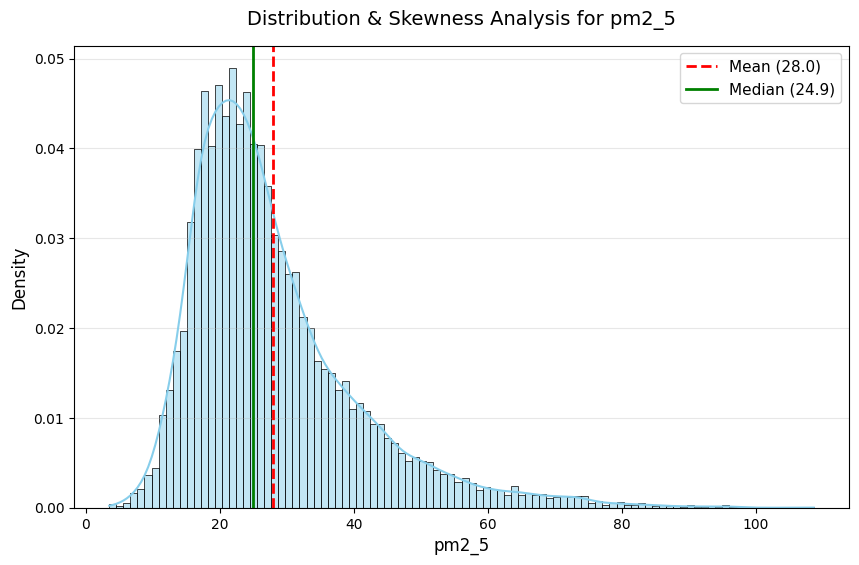

In [31]:
plot_distribution_profile(df, "pm2_5")

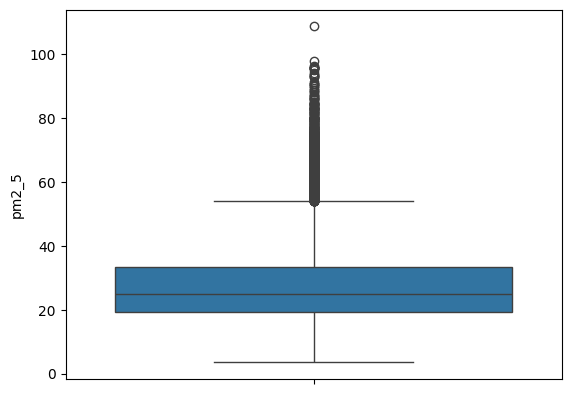

          PM2_5 OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 3.50
Upper Whisker Boundary : 53.90
---------------------------------------------
Low Outliers (< 3.50)  : 0 (0.000%)
High Outliers (> 53.90) : 844 (4.677%)
---------------------------------------------
Total Outliers Found   : 844 (4.677%)
Clean Records remaining: 17,202


In [32]:
check_outliers_and_plot_box(df,"pm2_5")

- Right skewed
- ~5% outlier only outside the upper whisker boundary

#### b. `pm10` column:
PM10 means particulate matter with a diameter of 10 micrometers or smaller (about one-seventh the width of a human hair). It is a measure of coarse dust, smoke, soot, and liquid droplets mixed in the air


In [33]:
df["pm10"].describe()

,pm10
count,18046.000000
mean,55.701180
std,32.289981
min,3.700000
25%,36.100000
50%,48.700000
75%,66.800000
max,504.800000


      DISTRIBUTION PROFILE: PM10      
Skewness Score : 3.0012
Skewness Type  : Positively Skewed (Right-tailed)
---------------------------------------------
Mean Value     : 55.70
Median Value   : 48.70
Difference     : 7.00


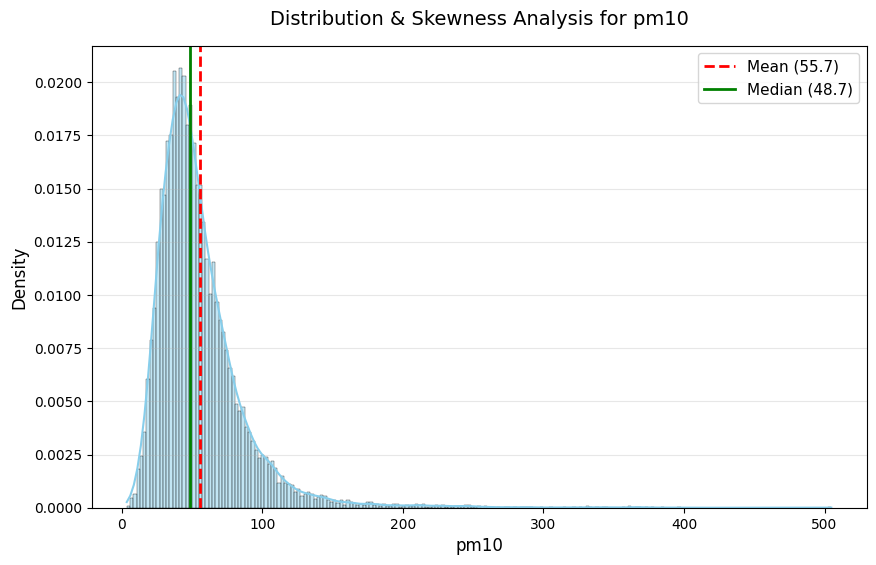

In [34]:
plot_distribution_profile(df, "pm10")

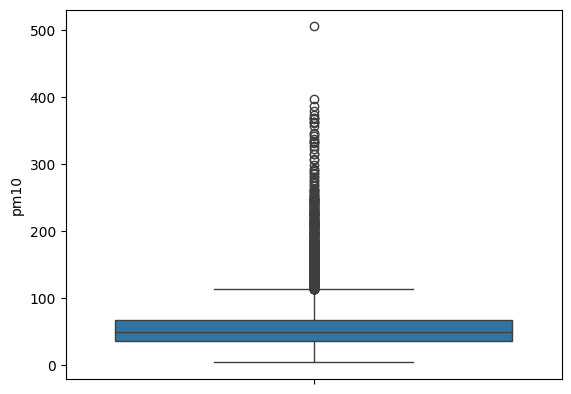

          PM10 OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 3.70
Upper Whisker Boundary : 112.70
---------------------------------------------
Low Outliers (< 3.70)  : 0 (0.000%)
High Outliers (> 112.70) : 810 (4.489%)
---------------------------------------------
Total Outliers Found   : 810 (4.489%)
Clean Records remaining: 17,236


In [35]:
check_outliers_and_plot_box(df,"pm10")

- highly right skewed
- ~4.5% outliers only outside the upper whisker boundary

#### c. `carbon_monoxide` column:
The `carbon_monoxide` column records ambient Carbon Monoxide concentrations, which serve as one of the major criteria pollutants used to calculate the localized Air Quality Index (AQI). CO is a hazardous, odorless gas primarily emitted by vehicle exhaust and industrial combustion.

In [36]:
df["carbon_monoxide"].describe()

,carbon_monoxide
count,18046.000000
mean,501.389311
std,443.651622
min,46.000000
25%,222.000000
50%,327.000000
75%,623.000000
max,4515.000000


      DISTRIBUTION PROFILE: CARBON_MONOXIDE      
Skewness Score : 2.5156
Skewness Type  : Positively Skewed (Right-tailed)
---------------------------------------------
Mean Value     : 501.39
Median Value   : 327.00
Difference     : 174.39


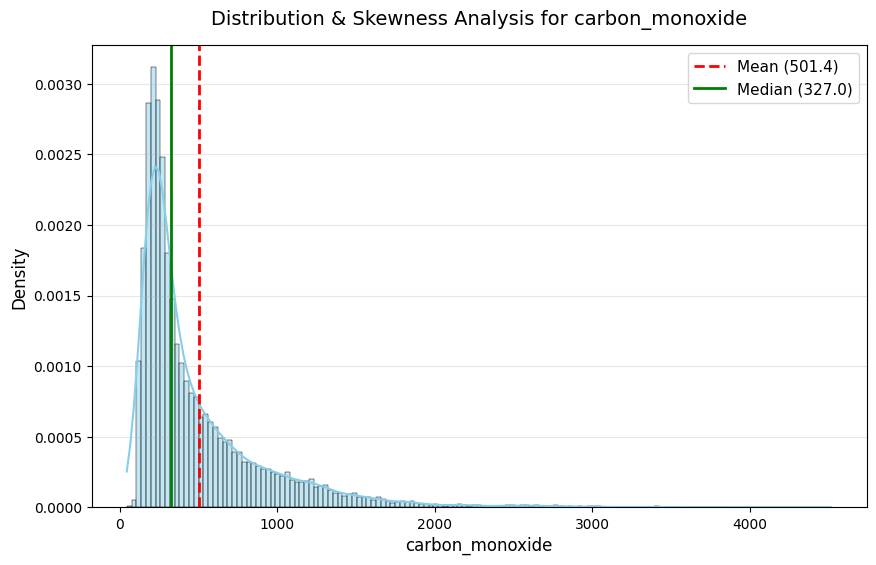

In [37]:
plot_distribution_profile(df, "carbon_monoxide")

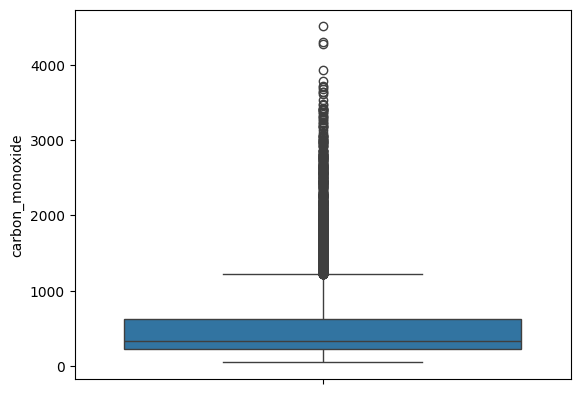

          CARBON_MONOXIDE OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 46.00
Upper Whisker Boundary : 1224.00
---------------------------------------------
Low Outliers (< 46.00)  : 0 (0.000%)
High Outliers (> 1224.00) : 1,288 (7.137%)
---------------------------------------------
Total Outliers Found   : 1,288 (7.137%)
Clean Records remaining: 16,758


In [38]:
check_outliers_and_plot_box(df,"carbon_monoxide")

- Strongly right skewed (skew = 2.52)
- Mean (501.39) well above median (327.00), a gap of 174.39 — a few high-pollution hours are pulling the average up substantially
- ~7.1% outliers, all on the upper (high-pollution) side — consistent with occasional traffic/combustion spikes rather than sensor noise

#### d. `nitrogen_dioxide` column:
The `nitrogen_dioxide` column measures ambient Nitrogen Dioxide concentrations, a highly reactive gas that serves as a core component in determining the overall Air Quality Index (AQI). $\text{NO}_2$ forms primarily from high-temperature fuel combustion, with major sources including motor vehicle engines, power plants, and heavy off-road equipment. Monitoring $\text{NO}_2$ within the AQI framework is vital because it acts as a precursor to both ground-level ozone $\text{O}_3$ and fine particulate matter $\text{NO}_2$, making it a key indicator of traffic-related photochemical smog and acute respiratory health risks.

In [39]:
df["nitrogen_dioxide"].describe()

,nitrogen_dioxide
count,18046.000000
mean,19.896947
std,18.429160
min,0.000000
25%,7.300000
50%,13.100000
75%,26.200000
max,138.500000


      DISTRIBUTION PROFILE: NITROGEN_DIOXIDE      
Skewness Score : 1.9738
Skewness Type  : Positively Skewed (Right-tailed)
---------------------------------------------
Mean Value     : 19.90
Median Value   : 13.10
Difference     : 6.80


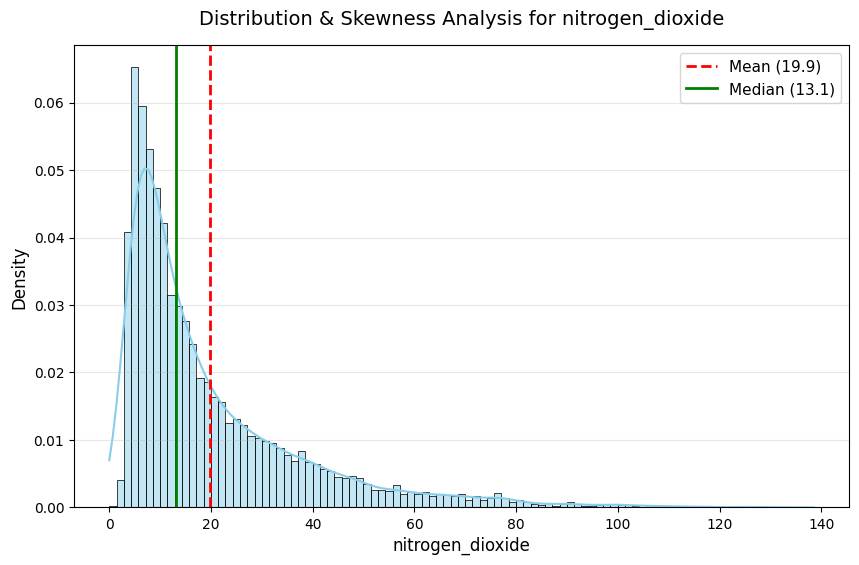

In [40]:
plot_distribution_profile(df, "nitrogen_dioxide")

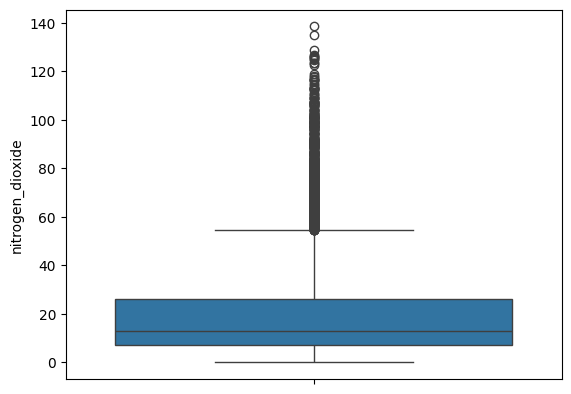

          NITROGEN_DIOXIDE OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 0.00
Upper Whisker Boundary : 54.50
---------------------------------------------
Low Outliers (< 0.00)  : 0 (0.000%)
High Outliers (> 54.50) : 1,115 (6.179%)
---------------------------------------------
Total Outliers Found   : 1,115 (6.179%)
Clean Records remaining: 16,931


In [41]:
check_outliers_and_plot_box(df,"nitrogen_dioxide")

- Strongly right skewed (skew = 1.97)
- Mean (19.90) notably above median (13.10) — a similar spike-driven pattern to carbon_monoxide, expected since both are traffic/combustion-sourced
- ~6.2% outliers, all on the upper side

#### e. `sulphur_dioxide` column:
The sulphur_dioxide $(\text{SO}_{2})$ column tracks ambient levels of a highly reactive gas that is an official US EPA criteria pollutant used to calculate the daily AQI. $\text{SO}_{2}$ enters the atmosphere primarily through the burning of fossil fuels at power plants, industrial facilities, and from heavy machinery or ships operating on high-sulfur diesel fuel. Monitoring this column is critical because atmospheric $\text{SO}_{2}$ reacts with other compounds to form secondary fine particulate matter $\text{PM}_{2.5}$ and is the primary driver behind acid rain.

In [42]:
df["sulphur_dioxide"].describe()

,sulphur_dioxide
count,18046.000000
mean,13.828959
std,8.630047
min,2.600000
25%,7.200000
50%,12.100000
75%,17.700000
max,65.400000


      DISTRIBUTION PROFILE: SULPHUR_DIOXIDE      
Skewness Score : 1.5082
Skewness Type  : Positively Skewed (Right-tailed)
---------------------------------------------
Mean Value     : 13.83
Median Value   : 12.10
Difference     : 1.73


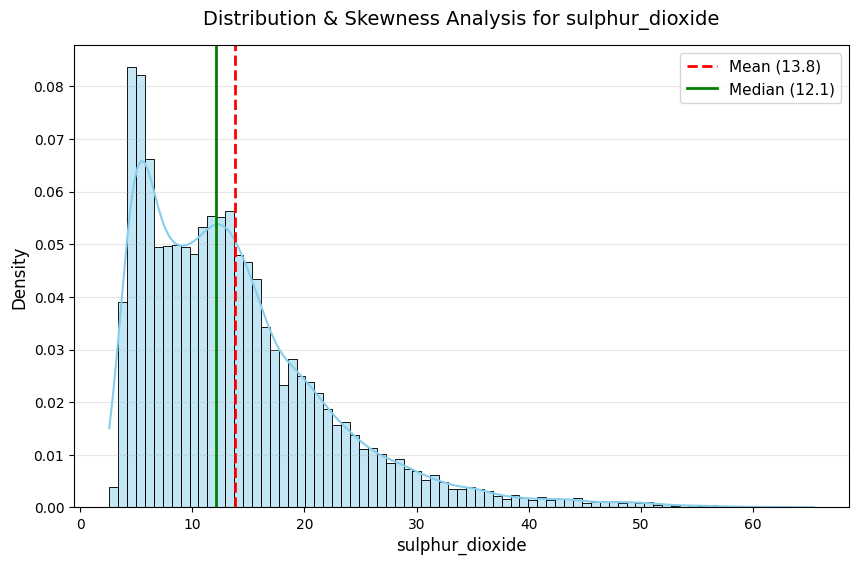

In [43]:
plot_distribution_profile(df, "sulphur_dioxide")

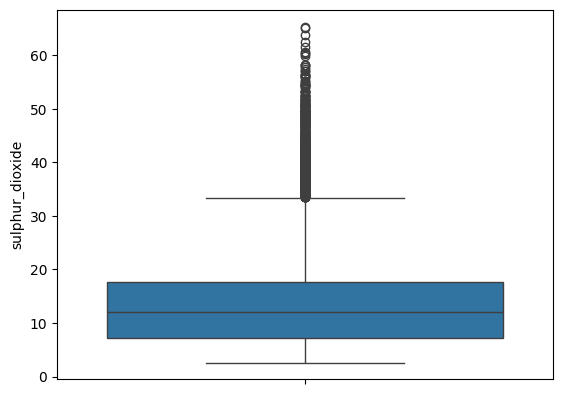

          SULPHUR_DIOXIDE OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 2.60
Upper Whisker Boundary : 33.40
---------------------------------------------
Low Outliers (< 2.60)  : 0 (0.000%)
High Outliers (> 33.40) : 639 (3.541%)
---------------------------------------------
Total Outliers Found   : 639 (3.541%)
Clean Records remaining: 17,407


In [44]:
check_outliers_and_plot_box(df,"sulphur_dioxide")

- Right skewed (skew = 1.51)
- Mean (13.83) close to median (12.10), a smaller gap than CO/NO2
- ~3.5% outliers, all upper-side — the mildest skew among the combustion-related gases

#### f. `ozone` column:

In [45]:
df["ozone"].describe()

,ozone
count,18046.000000
mean,70.338302
std,38.720373
min,0.000000
25%,43.000000
50%,61.000000
75%,92.000000
max,213.000000


      DISTRIBUTION PROFILE: OZONE      
Skewness Score : 0.7801
Skewness Type  : Positively Skewed (Right-tailed)
---------------------------------------------
Mean Value     : 70.34
Median Value   : 61.00
Difference     : 9.34


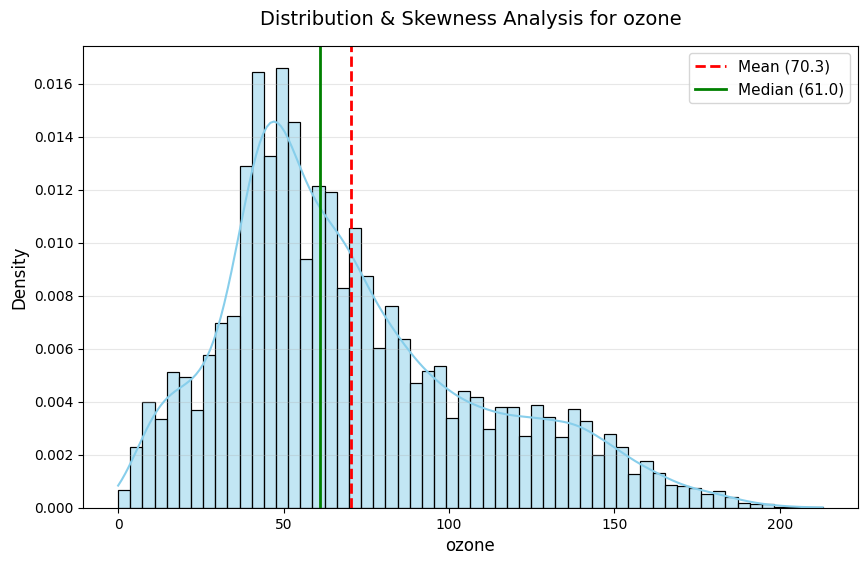

In [46]:
plot_distribution_profile(df, "ozone")

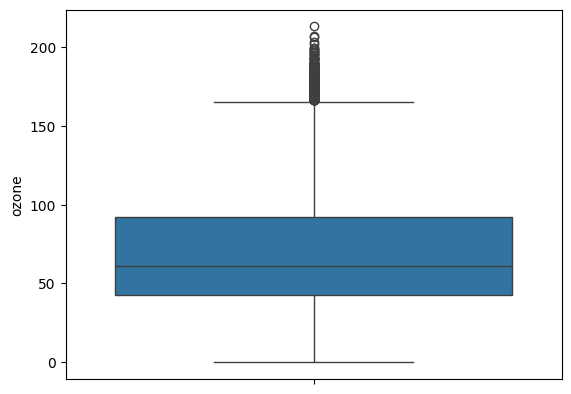

          OZONE OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 0.00
Upper Whisker Boundary : 165.00
---------------------------------------------
Low Outliers (< 0.00)  : 0 (0.000%)
High Outliers (> 165.00) : 304 (1.685%)
---------------------------------------------
Total Outliers Found   : 304 (1.685%)
Clean Records remaining: 17,742


In [47]:
check_outliers_and_plot_box(df,"ozone")

- Moderately right skewed (skew = 0.78)
- Mean (70.34) and median (61.00) reasonably close
- Only ~1.7% outliers — the most well-behaved distribution among the pollutant columns, consistent with ozone's near-zero correlation with AQI found later

#### g. `dust` column:

In [48]:
df["dust"].describe()

,dust
count,18046.000000
mean,48.731907
std,55.607814
min,0.000000
25%,12.000000
50%,35.000000
75%,66.000000
max,597.000000


      DISTRIBUTION PROFILE: DUST      
Skewness Score : 3.1254
Skewness Type  : Positively Skewed (Right-tailed)
---------------------------------------------
Mean Value     : 48.73
Median Value   : 35.00
Difference     : 13.73


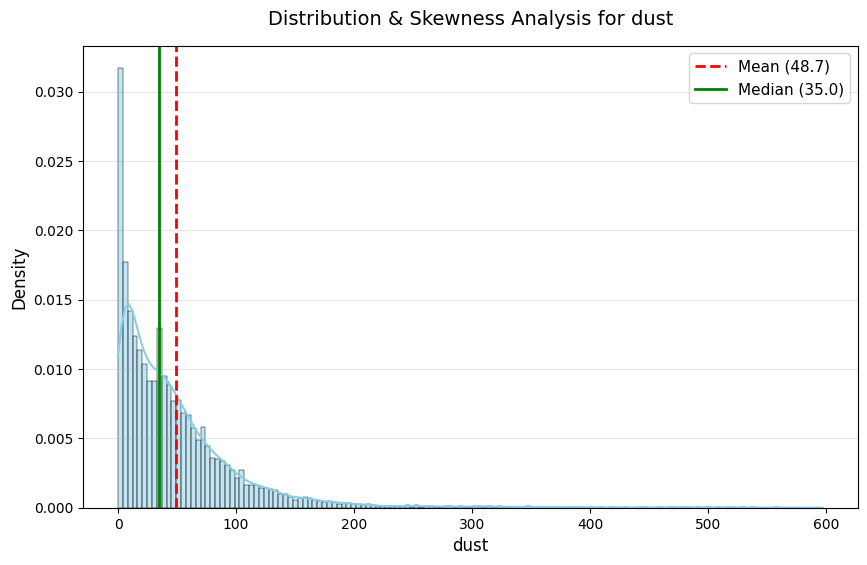

In [49]:
plot_distribution_profile(df, "dust")

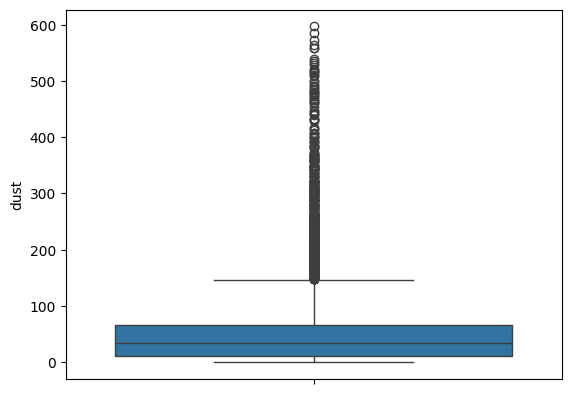

          DUST OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 0.00
Upper Whisker Boundary : 147.00
---------------------------------------------
Low Outliers (< 0.00)  : 0 (0.000%)
High Outliers (> 147.00) : 848 (4.699%)
---------------------------------------------
Total Outliers Found   : 848 (4.699%)
Clean Records remaining: 17,198


In [50]:
check_outliers_and_plot_box(df,"dust")

- Strongly right skewed (skew = 3.13) — the most skewed pollutant column
- Mean (48.73) well above median (35.00)
- ~4.7% outliers, all upper-side

#### h. `us_aqi` column:

In [51]:
df["us_aqi"].describe()

,us_aqi
count,18046.000000
mean,87.612657
std,21.810594
min,41.000000
25%,73.000000
50%,82.000000
75%,97.000000
max,173.000000


      DISTRIBUTION PROFILE: US_AQI      
Skewness Score : 1.2067
Skewness Type  : Positively Skewed (Right-tailed)
---------------------------------------------
Mean Value     : 87.61
Median Value   : 82.00
Difference     : 5.61


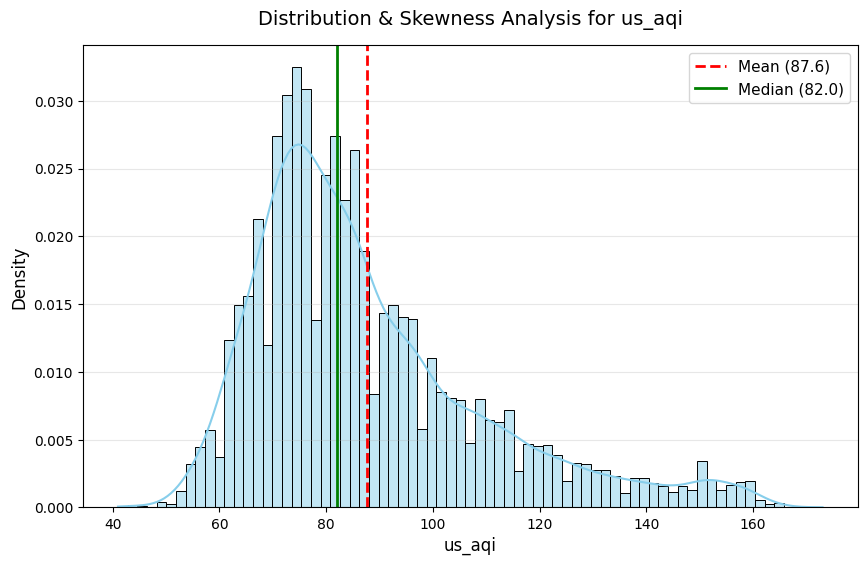

In [52]:
plot_distribution_profile(df, "us_aqi")

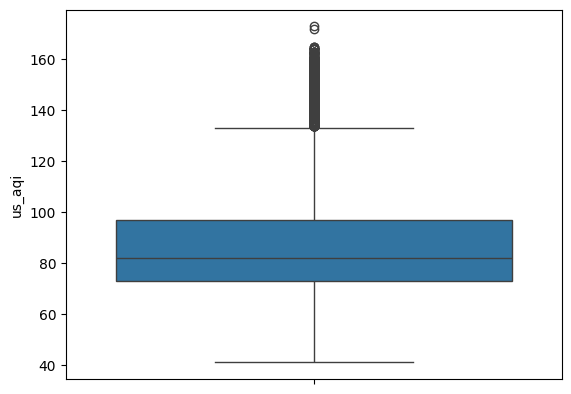

          US_AQI OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 41.00
Upper Whisker Boundary : 133.00
---------------------------------------------
Low Outliers (< 41.00)  : 0 (0.000%)
High Outliers (> 133.00) : 933 (5.170%)
---------------------------------------------
Total Outliers Found   : 933 (5.170%)
Clean Records remaining: 17,113


In [53]:
check_outliers_and_plot_box(df,"us_aqi")

- Right skewed (skew = 1.21) — the target variable
- Mean (87.61) above median (82.00)
- ~5.2% outliers, all on the upper (unhealthy AQI) side — these represent genuine severe pollution episodes and should be kept, not removed, since capturing them is the point of the forecasting task

#### i. `temperature_2m` column:

In [54]:
df["temperature_2m"].describe()

,temperature_2m
count,18046.000000
mean,26.719777
std,4.645230
min,9.300000
25%,24.100000
50%,27.700000
75%,29.800000
max,41.200000


      DISTRIBUTION PROFILE: TEMPERATURE_2M      
Skewness Score : -0.6980
Skewness Type  : Negatively Skewed (Left-tailed)
---------------------------------------------
Mean Value     : 26.72
Median Value   : 27.70
Difference     : 0.98


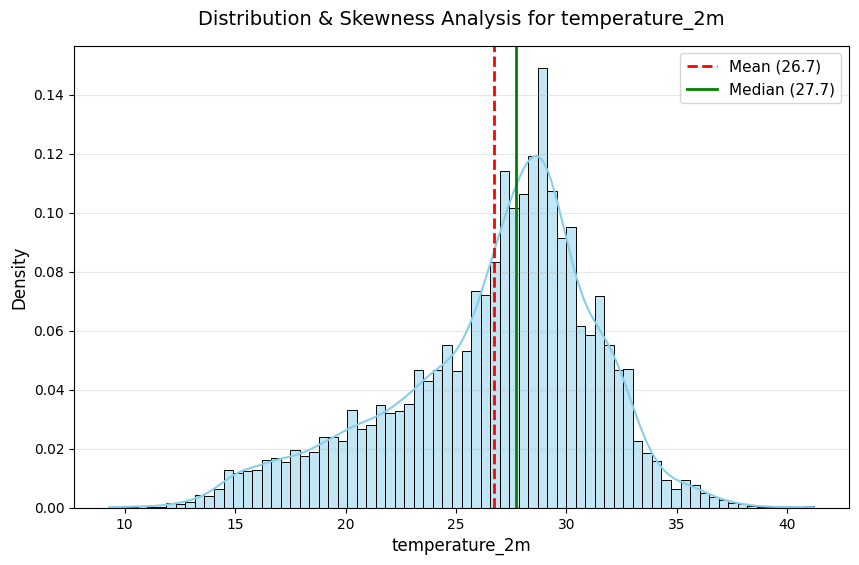

In [55]:
plot_distribution_profile(df, "temperature_2m")

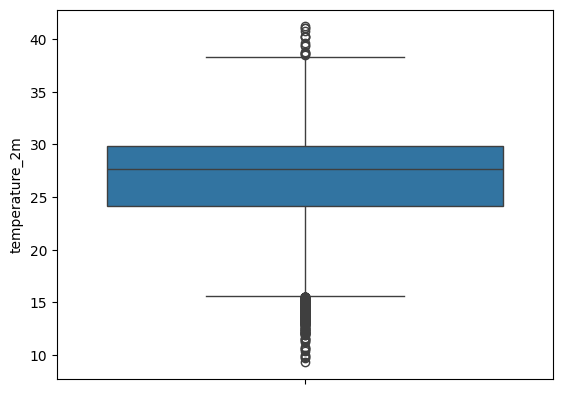

          TEMPERATURE_2M OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 15.60
Upper Whisker Boundary : 38.30
---------------------------------------------
Low Outliers (< 15.60)  : 414 (2.294%)
High Outliers (> 38.30) : 15 (0.083%)
---------------------------------------------
Total Outliers Found   : 429 (2.377%)
Clean Records remaining: 17,617


In [56]:
check_outliers_and_plot_box(df,"temperature_2m")

- Mildly left skewed (skew = -0.70), the first column skewed in this direction
- Mean (26.72) slightly below median (27.70)
- ~2.4% outliers, split across both tails (2.29% low, 0.08% high) — unlike the pollutant columns, temperature has genuine outliers on the cold side too, consistent with Karachi's mild winters

#### j. `relative_humidity_2m` column:

In [57]:
df["relative_humidity_2m"].describe()

,relative_humidity_2m
count,18046.000000
mean,65.296188
std,21.169192
min,5.000000
25%,51.000000
50%,70.000000
75%,82.000000
max,100.000000


      DISTRIBUTION PROFILE: RELATIVE_HUMIDITY_2M      
Skewness Score : -0.7000
Skewness Type  : Negatively Skewed (Left-tailed)
---------------------------------------------
Mean Value     : 65.30
Median Value   : 70.00
Difference     : 4.70


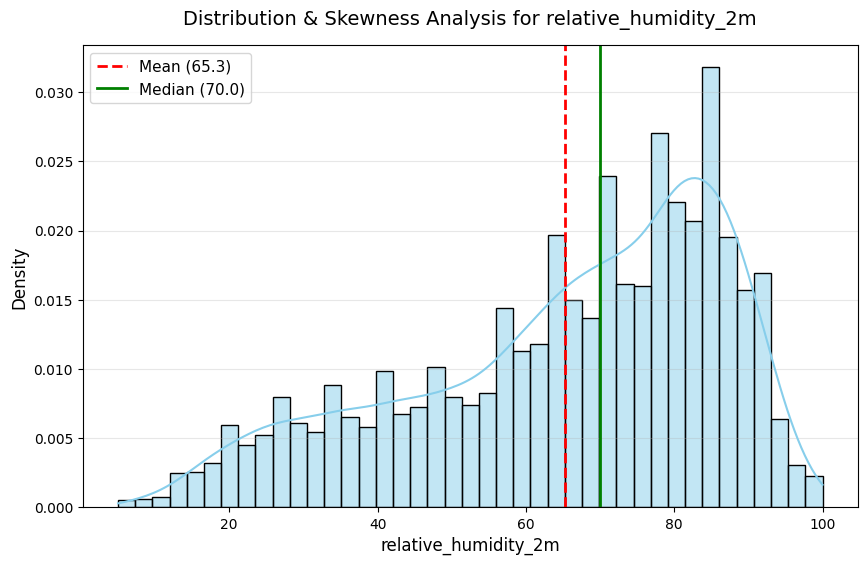

In [58]:
plot_distribution_profile(df, "relative_humidity_2m")

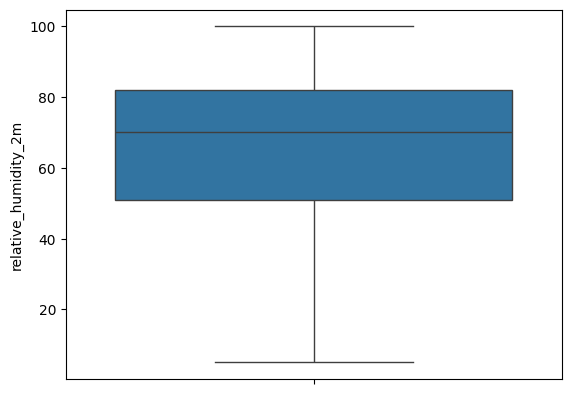

          RELATIVE_HUMIDITY_2M OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 5.00
Upper Whisker Boundary : 100.00
---------------------------------------------
Low Outliers (< 5.00)  : 0 (0.000%)
High Outliers (> 100.00) : 0 (0.000%)
---------------------------------------------
Total Outliers Found   : 0 (0.000%)
Clean Records remaining: 18,046


In [59]:
check_outliers_and_plot_box(df,"relative_humidity_2m")

- Mildly left skewed (skew = -0.70)
- Mean (65.30) below median (70.00)
- 0% outliers — a well-bounded, well-behaved distribution

#### k. `wind_speed_10m` column:

In [60]:
df["wind_speed_10m"].describe()

,wind_speed_10m
count,18046.000000
mean,11.733259
std,5.361882
min,0.000000
25%,7.900000
50%,11.200000
75%,15.000000
max,46.600000


      DISTRIBUTION PROFILE: WIND_SPEED_10M      
Skewness Score : 0.8171
Skewness Type  : Positively Skewed (Right-tailed)
---------------------------------------------
Mean Value     : 11.73
Median Value   : 11.20
Difference     : 0.53


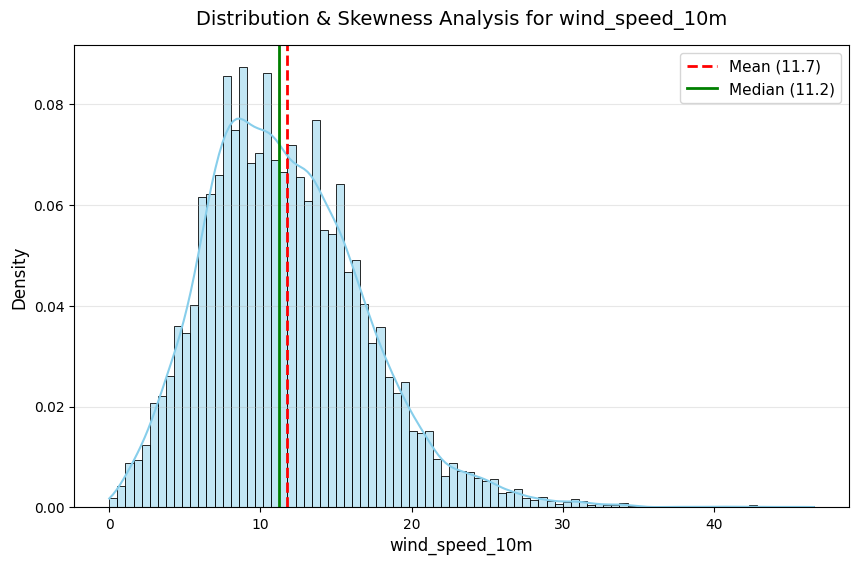

In [61]:
plot_distribution_profile(df, "wind_speed_10m")

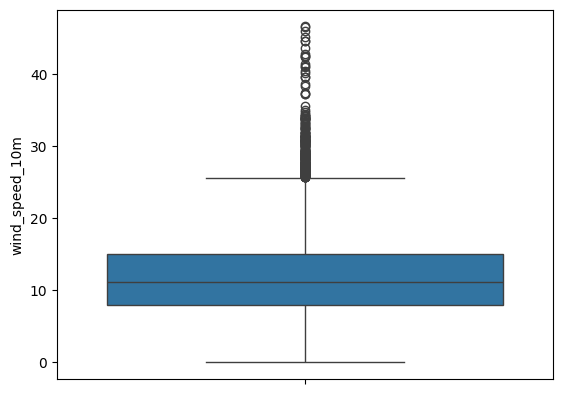

          WIND_SPEED_10M OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 0.00
Upper Whisker Boundary : 25.60
---------------------------------------------
Low Outliers (< 0.00)  : 0 (0.000%)
High Outliers (> 25.60) : 267 (1.480%)
---------------------------------------------
Total Outliers Found   : 267 (1.480%)
Clean Records remaining: 17,779


In [62]:
check_outliers_and_plot_box(df,"wind_speed_10m")

- Moderately right skewed (skew = 0.82)
- Mean (11.73) close to median (11.20)
- ~1.5% outliers, upper-side only

#### l. `wind_direction_10m` column:

In [63]:
df["wind_direction_10m"].describe()

,wind_direction_10m
count,18046.000000
mean,220.165023
std,89.673131
min,1.000000
25%,216.000000
50%,247.000000
75%,269.000000
max,360.000000


      DISTRIBUTION PROFILE: WIND_DIRECTION_10M      
Skewness Score : -1.1693
Skewness Type  : Negatively Skewed (Left-tailed)
---------------------------------------------
Mean Value     : 220.17
Median Value   : 247.00
Difference     : 26.83


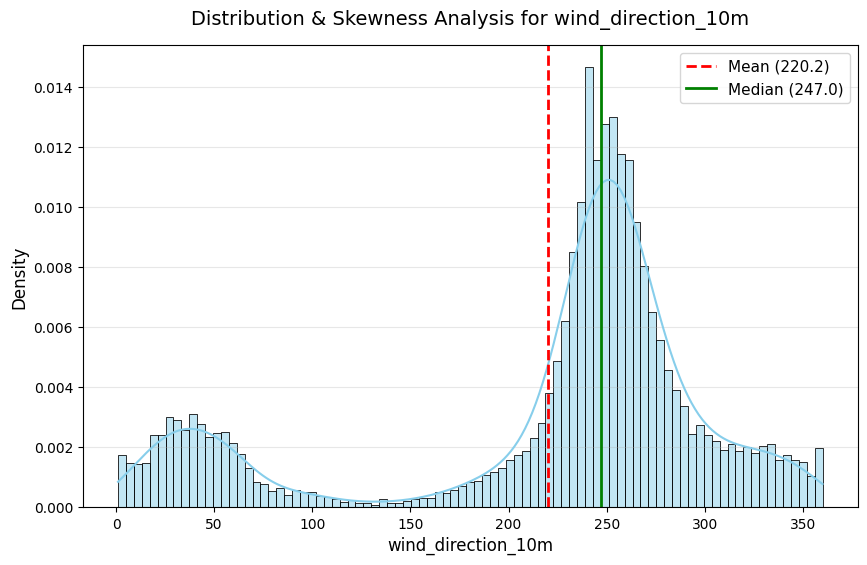

In [64]:
plot_distribution_profile(df, "wind_direction_10m")

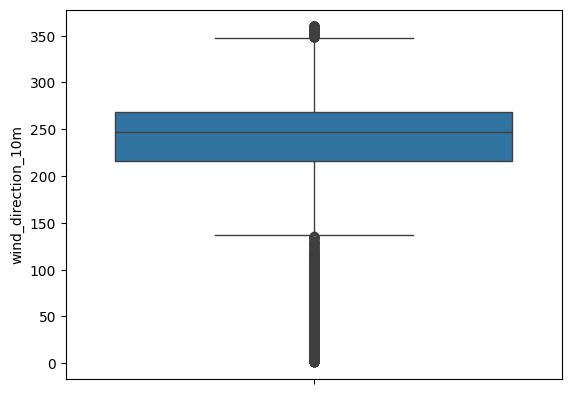

          WIND_DIRECTION_10M OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 137.00
Upper Whisker Boundary : 348.00
---------------------------------------------
Low Outliers (< 137.00)  : 3,257 (18.048%)
High Outliers (> 348.00) : 302 (1.674%)
---------------------------------------------
Total Outliers Found   : 3,559 (19.722%)
Clean Records remaining: 14,487


In [65]:
check_outliers_and_plot_box(df,"wind_direction_10m")

- Left skewed (skew = -1.17), but this metric is misleading here: wind direction is a **circular** variable (0° and 360° represent the same direction), so standard skewness/outlier statistics don't really apply in the usual sense
- ~19.7% flagged as "outliers" (18.0% low, 1.7% high) — this unusually high number is an artifact of the circular wraparound, not genuine extreme values. This column will be cyclic-encoded (sin/cos) later instead of relying on this outlier analysis

#### m. `surface_pressure` column:

In [66]:
df["surface_pressure"].describe()

,surface_pressure
count,18046.000000
mean,1007.612964
std,6.614452
min,992.800000
25%,1002.200000
50%,1007.400000
75%,1013.200000
max,1024.400000


      DISTRIBUTION PROFILE: SURFACE_PRESSURE      
Skewness Score : 0.0407
Skewness Type  : Approximately Symmetric
---------------------------------------------
Mean Value     : 1007.61
Median Value   : 1007.40
Difference     : 0.21


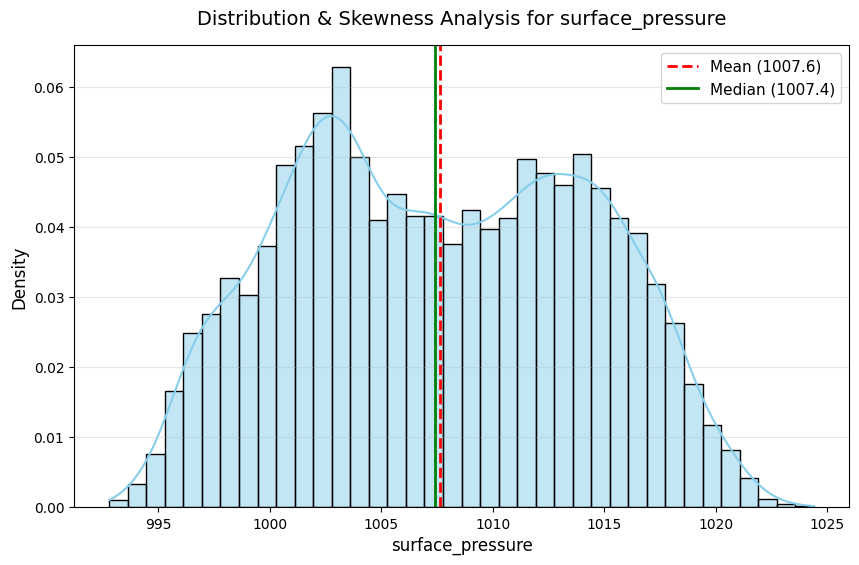

In [67]:
plot_distribution_profile(df, "surface_pressure")

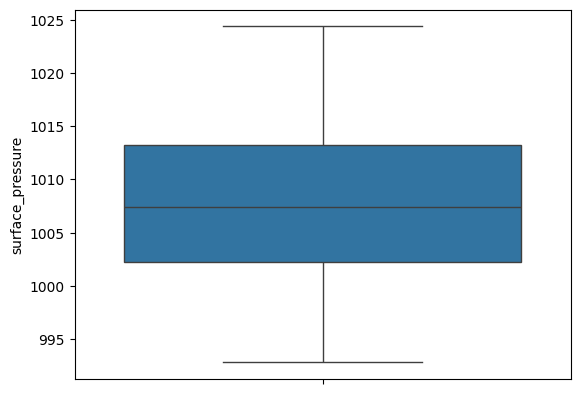

          SURFACE_PRESSURE OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 992.80
Upper Whisker Boundary : 1024.40
---------------------------------------------
Low Outliers (< 992.80)  : 0 (0.000%)
High Outliers (> 1024.40) : 0 (0.000%)
---------------------------------------------
Total Outliers Found   : 0 (0.000%)
Clean Records remaining: 18,046


In [68]:
check_outliers_and_plot_box(df,"surface_pressure")

- Approximately symmetric (skew = 0.04)
- Mean (1007.61) and median (1007.40) nearly identical
- 0% outliers — the cleanest, most normally-distributed column in the dataset

#### n. `precipitation` column:

In [69]:
df["precipitation"].describe()

,precipitation
count,18046.000000
mean,0.032234
std,0.379387
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,16.500000


      DISTRIBUTION PROFILE: PRECIPITATION      
Skewness Score : 24.4446
Skewness Type  : Positively Skewed (Right-tailed)
---------------------------------------------
Mean Value     : 0.03
Median Value   : 0.00
Difference     : 0.03


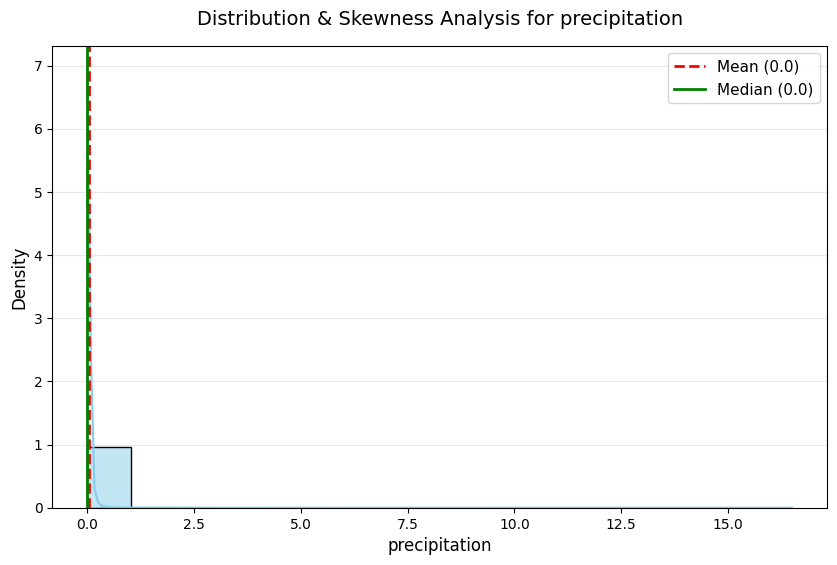

In [70]:
plot_distribution_profile(df, "precipitation")

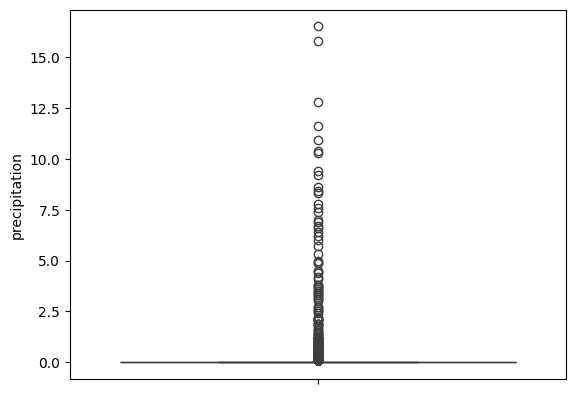

          PRECIPITATION OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 0.00
Upper Whisker Boundary : 0.00
---------------------------------------------
Low Outliers (< 0.00)  : 0 (0.000%)
High Outliers (> 0.00) : 1,357 (7.520%)
---------------------------------------------
Total Outliers Found   : 1,357 (7.520%)
Clean Records remaining: 16,689


In [71]:
check_outliers_and_plot_box(df,"precipitation")

- Extremely right skewed (skew = 24.44) — by far the most skewed column, expected since Karachi has long dry spells punctuated by rare rain events
- Median is 0.00 (most hours have no rain at all); mean (0.03) is pulled up by rare events
- ~7.5% "outliers" — since the whisker boundary is 0, this simply flags any hour with measurable rainfall, not true extreme values

#### o. `cloud_cover` column:

In [72]:
df["cloud_cover"].describe()

,cloud_cover
count,18046.000000
mean,32.972321
std,39.421411
min,0.000000
25%,0.000000
50%,11.000000
75%,71.000000
max,100.000000


      DISTRIBUTION PROFILE: CLOUD_COVER      
Skewness Score : 0.7603
Skewness Type  : Positively Skewed (Right-tailed)
---------------------------------------------
Mean Value     : 32.97
Median Value   : 11.00
Difference     : 21.97


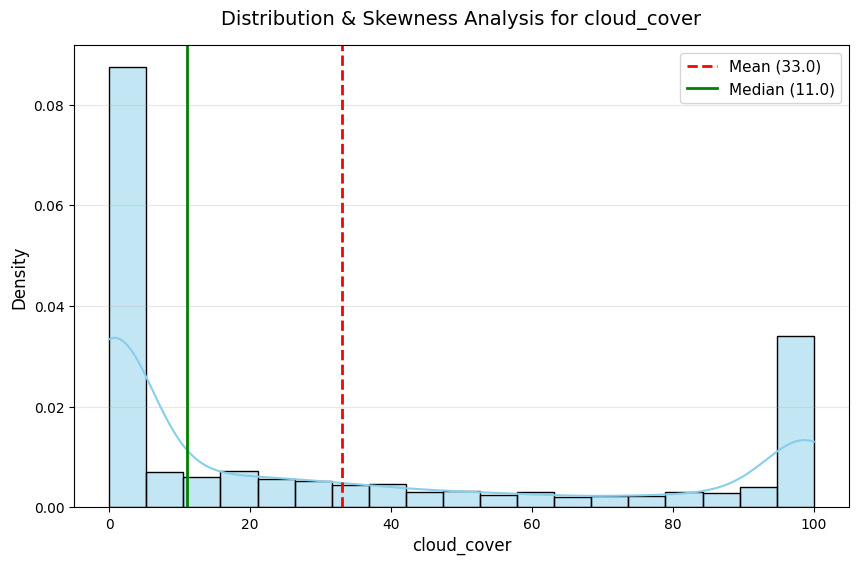

In [73]:
plot_distribution_profile(df, "cloud_cover")

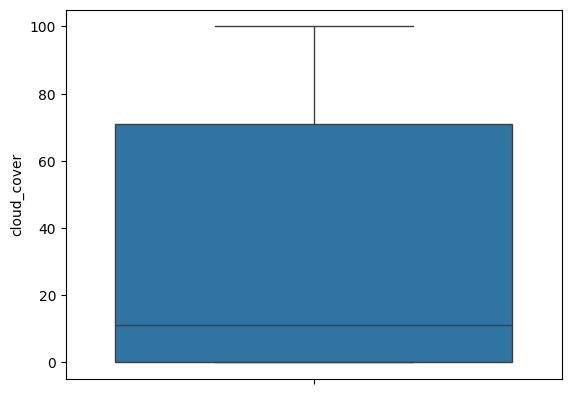

          CLOUD_COVER OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 0.00
Upper Whisker Boundary : 100.00
---------------------------------------------
Low Outliers (< 0.00)  : 0 (0.000%)
High Outliers (> 100.00) : 0 (0.000%)
---------------------------------------------
Total Outliers Found   : 0 (0.000%)
Clean Records remaining: 18,046


In [74]:
check_outliers_and_plot_box(df,"cloud_cover")

- Moderately right skewed (skew = 0.76)
- Large mean-median gap (32.97 vs 11.00) — suggests a mix of mostly-clear days (near 0% cover) and a distinct subset of heavily overcast days pulling the mean up
- 0% outliers despite the skew — the distribution is skewed but well within [0, 100] bounds

### 2. Temporal Patterns (AQI):
#### a. AQI vs time series

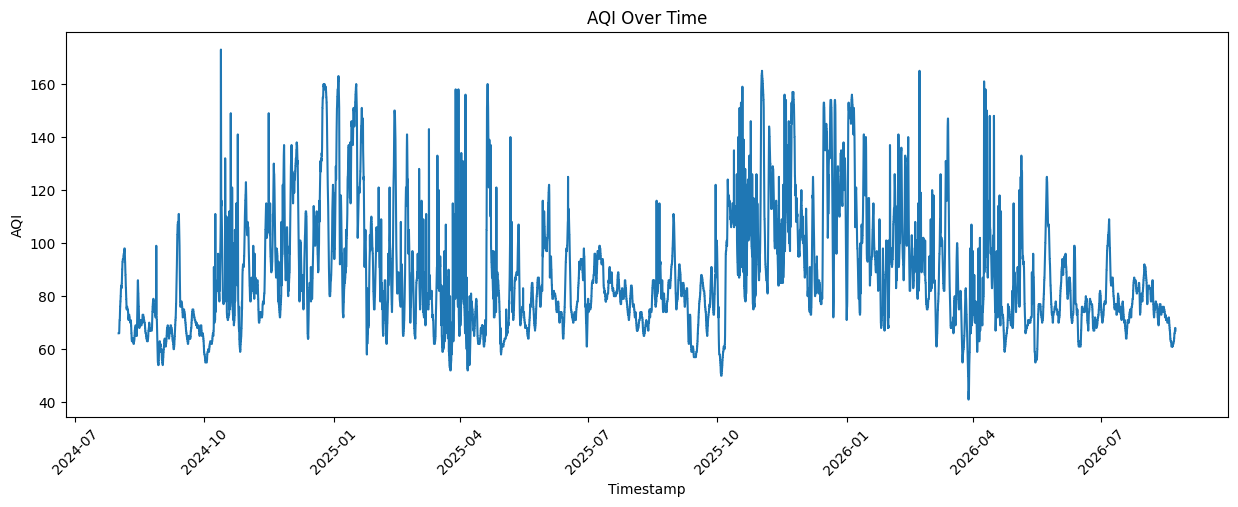

In [75]:
plt.figure(figsize=(15, 5))

sns.lineplot(df["us_aqi"])

plt.xlabel("Timestamp")
plt.ylabel("AQI")
plt.title("AQI Over Time")
plt.xticks(rotation=45)
plt.show()

- AQI ranges from 41 to 173 across the ~2-year dataset (Aug 2024 – Aug 2026), with a mean around 87.6
- The series shows clear multi-day pollution episodes (sustained elevated stretches) rather than pure random noise, consistent with the strong short-term autocorrelation found later in the ACF/PACF analysis
- No obvious long-term trend (e.g. steadily worsening or improving over the two years) is visible by eye, which lines up with the ADF test later confirming the series is stationary

#### b. Average AQI by hour:

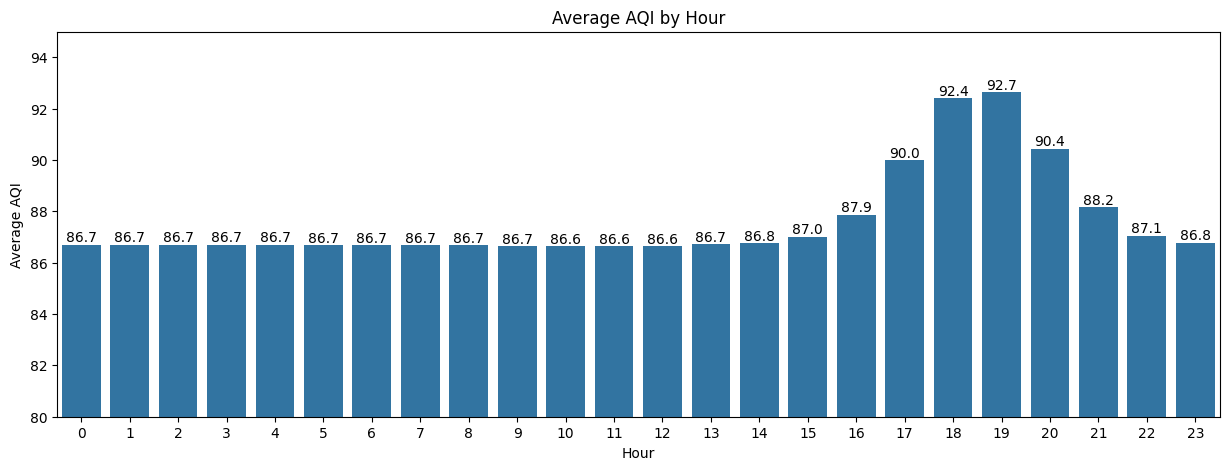

In [76]:
plt.figure(figsize=(15, 5))
hour_groupby = df.groupby("hour")["us_aqi"].mean()

ax = sns.barplot(hour_groupby)

plt.xlabel("Hour")
plt.ylabel("Average AQI")
plt.title("Average AQI by Hour")
plt.ylim(80,95)

ax.bar_label(ax.containers[0], fmt="%.1f")

plt.show()

- AQI is fairly flat through most of the day (~86.6-86.8) but rises noticeably in the evening, peaking around hour 19 (~92.7) before declining back down overnight
- The trough is around hour 10 (~86.6)
- The swing is modest (~6 points between peak and trough) — hour-of-day alone is a weak signal, though the evening peak is consistent with typical rush-hour/evening-inversion pollution buildup

#### c. Day-of-week pattern:

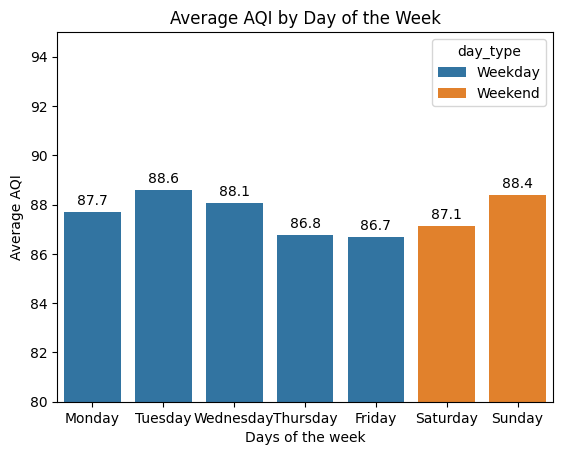

In [77]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_groupby = df.groupby("day_name")["us_aqi"].mean().reindex(day_order)

plot_df = day_groupby.reset_index()
plot_df["day_type"] = plot_df["day_name"].apply(
    lambda x: "Weekday" if x in ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
    else "Weekend"
)

ax = sns.barplot(
    data=plot_df,
    x="day_name",
    y="us_aqi",
    hue="day_type"
)

ax.bar_label(ax.containers[0], fmt="%.1f", padding=3)
ax.bar_label(ax.containers[1], fmt="%.1f", padding=3)

plt.xlabel("Days of the week")
plt.ylabel("Average AQI")
plt.title("Average AQI by Day of the Week")
plt.ylim(80, 95)
plt.show()

- AQI varies only mildly across the week (~86.7 to ~88.6)
- Tuesday (88.58) and Sunday (88.38) are the highest; Friday (86.68) and Thursday (86.77) are the lowest
- The pattern doesn't show a clean weekday-vs-weekend split — Sunday being nearly as high as Tuesday suggests day-of-week alone isn't a strong standalone driver of AQI here

#### d. Weekday vs weekend

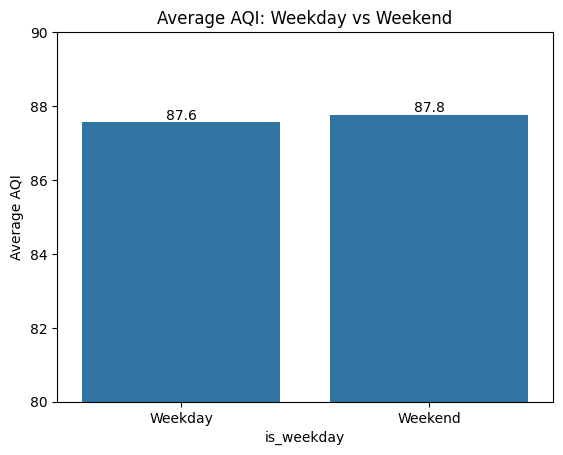

In [78]:
df["is_weekday"] = df["day_name"].apply(
    lambda x: "Weekday" if x in ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
    else "Weekend"
)


weekday_groupby = df.groupby("is_weekday")["us_aqi"].mean()

ax = sns.barplot(weekday_groupby)

plt.ylabel("Average AQI")
plt.title("Average AQI: Weekday vs Weekend")
plt.ylim(80,90)

ax.bar_label(ax.containers[0], fmt="%.1f")

plt.show()



- Weekday average (87.55) and weekend average (87.76) are nearly identical — under half a point apart
- This suggests traffic/weekday activity is not a dominant driver of AQI in this dataset, unlike what's often assumed for urban pollution — worth keeping as a weak feature rather than a strong one

#### e. Monthly pattern:

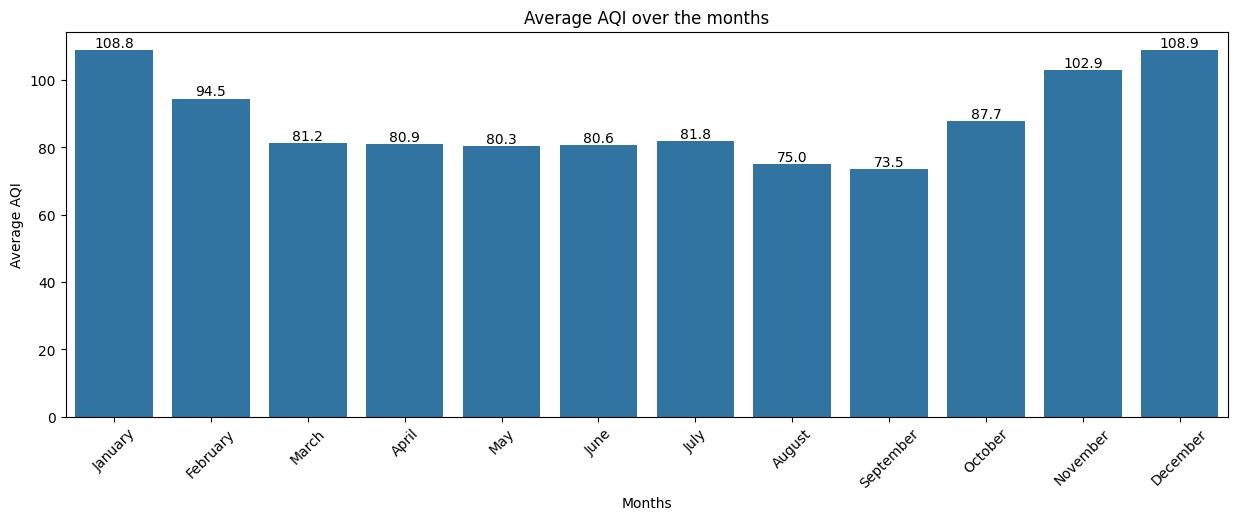

In [79]:
plt.figure(figsize=(15, 5))
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

month_groupby = df.groupby("month_name")["us_aqi"].mean().reindex(months_order)

ax = sns.barplot(month_groupby)

plt.xlabel("Months")
plt.ylabel("Average AQI")
plt.title("Average AQI over the months")
plt.xticks(rotation=45)

ax.bar_label(ax.containers[0], fmt="%.1f")

plt.show()



- A clear seasonal pattern: winter months are far more polluted than summer months
- Highest: December (108.93), January (108.77), November (102.91) — the winter smog season
- Lowest: September (73.50), August (74.99), May (80.35)
- The swing between the worst and best months is roughly 35 AQI points — by far the strongest temporal pattern found in this section, and consistent with well-documented winter smog/temperature-inversion effects in South Asian cities. This motivates the strong emphasis on month-based cyclic features in the modeling stage

#### f. 24-hour rolling mean/std:

In [80]:
# Calculate 24-hour rolling mean and standard deviation
df["rolling_mean_24h"] = df["us_aqi"].rolling(window=24).mean()
df["rolling_std_24h"] = df["us_aqi"].rolling(window=24).std()

- 24-hour rolling mean ranges from ~47 to ~163, showing that sustained pollution episodes (not just single-hour spikes) genuinely persist for a day or more at a time
- 24-hour rolling standard deviation ranges from near 0 up to ~34, averaging around 5.2 — most periods are fairly stable hour-to-hour, punctuated by distinct high-volatility episodes
- This is consistent with the bimodal AQI distribution found later in the pair plot: calmer "normal" periods and separate, more volatile "severe pollution" episodes

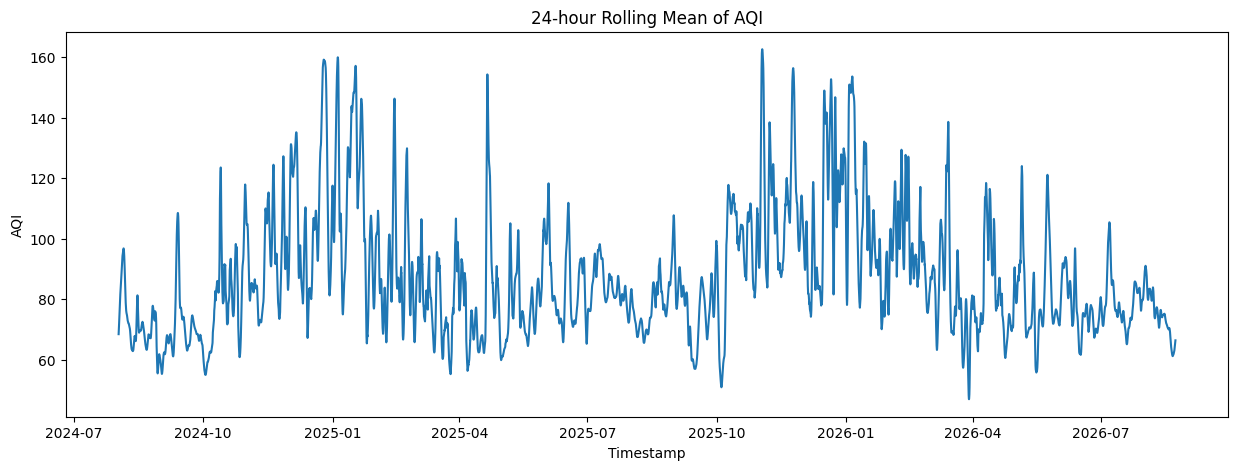

In [81]:
plt.figure(figsize=(15, 5))

sns.lineplot(
    df["rolling_mean_24h"]
)

plt.xlabel("Timestamp")
plt.ylabel("AQI")
plt.title("24-hour Rolling Mean of AQI")

plt.show()

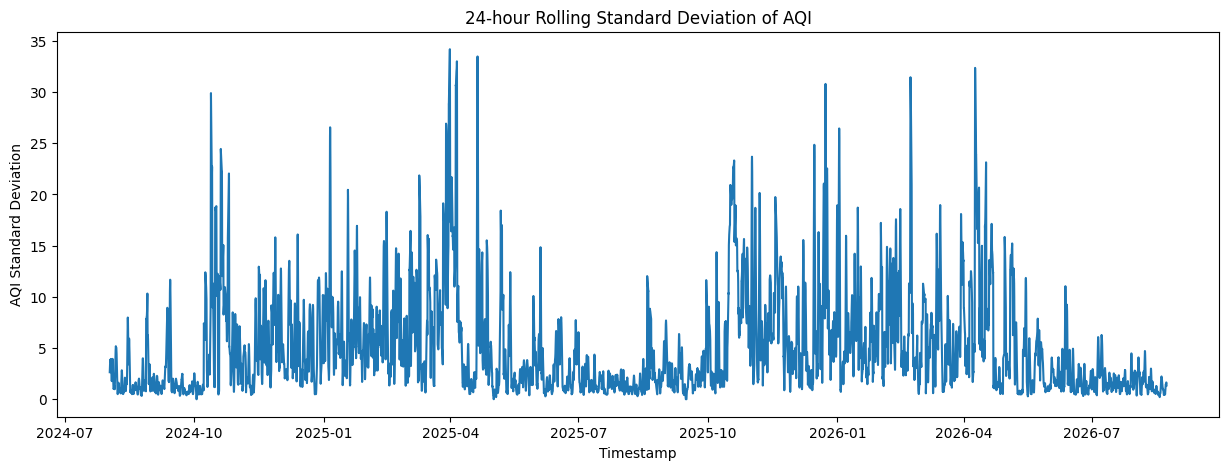

In [82]:
plt.figure(figsize=(15, 5))

sns.lineplot(
  df["rolling_std_24h"]
)

plt.xlabel("Timestamp")
plt.ylabel("AQI Standard Deviation")
plt.title("24-hour Rolling Standard Deviation of AQI")

plt.show()

### 3. Correlation matrix:

In [83]:
df_corr = df[['pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide',
       'sulphur_dioxide', 'ozone', 'dust', 'us_aqi', 'temperature_2m',
       'relative_humidity_2m', 'wind_speed_10m', 'wind_direction_10m',
       'surface_pressure', 'precipitation', 'cloud_cover']].corr()

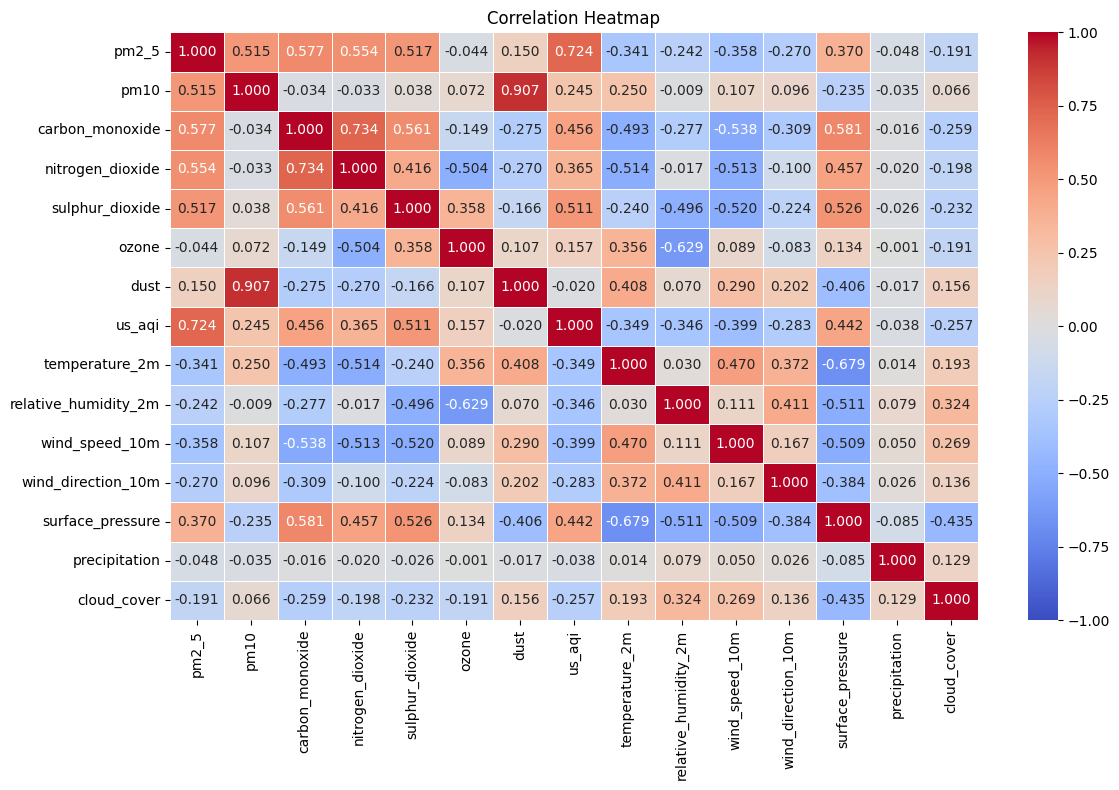

In [84]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df_corr,
    annot=True,       # Show correlation values
    fmt=".3f",        # Round to 2 decimal places
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

#### Correlation Heatmap Findings:

**AQI drivers:**
- `pm2_5` is the dominant driver of `us_aqi` (r=0.724) — expected, since PM2.5 is typically the primary component of AQI calculations
- `sulphur_dioxide` (r=0.511), `carbon_monoxide` (r=0.456), and `surface_pressure` (r=0.442) are moderate secondary drivers
- `pm10` correlates surprisingly weakly with AQI (r=0.245) despite being a major pollutant
- `ozone` is essentially uncorrelated with AQI (r=-0.020), suggesting it behaves independently of the main pollution signal

**Multicollinearity (relevant for feature selection):**
- `pm10` and `dust` are near-duplicates (r=0.907) — candidate for dropping one, or combining, especially for linear/regularized models
- `carbon_monoxide` and `nitrogen_dioxide` are strongly correlated (r=0.734), consistent with both being traffic/combustion-sourced
- `temperature_2m` and `surface_pressure` are strongly negatively correlated (r=-0.679), physically expected from pressure-system dynamics

**Weather-pollution relationships (data quality sanity check):**
- `wind_speed_10m` negatively correlates with `carbon_monoxide`, `nitrogen_dioxide`, `sulphur_dioxide` (r=-0.51 to -0.54) — higher wind disperses pollutants, as expected
- `surface_pressure` positively correlates with `carbon_monoxide` and `sulphur_dioxide` (r=0.58, 0.53) — stagnant high-pressure systems trap pollutants near the surface
- `relative_humidity_2m` negatively correlates with `ozone` (r=-0.629) — humid air suppresses photochemical ozone formation

**Implication for modeling:**
- Since correlations here only capture linear relationships, `ozone`'s near-zero correlation should be re-checked in the pair plot for nonlinear patterns before dropping it as a feature
- Multicollinear pairs (`pm10`/`dust`, `co`/`no2`) should be handled carefully if using linear models; tree-based models are more robust to this

###  4. Pair plot for bivariate analysis
- Focused on us_aqi + top correlated / notable features from the heatmap.
- including ozone despite low linear corr, to check for nonlinear relationships.

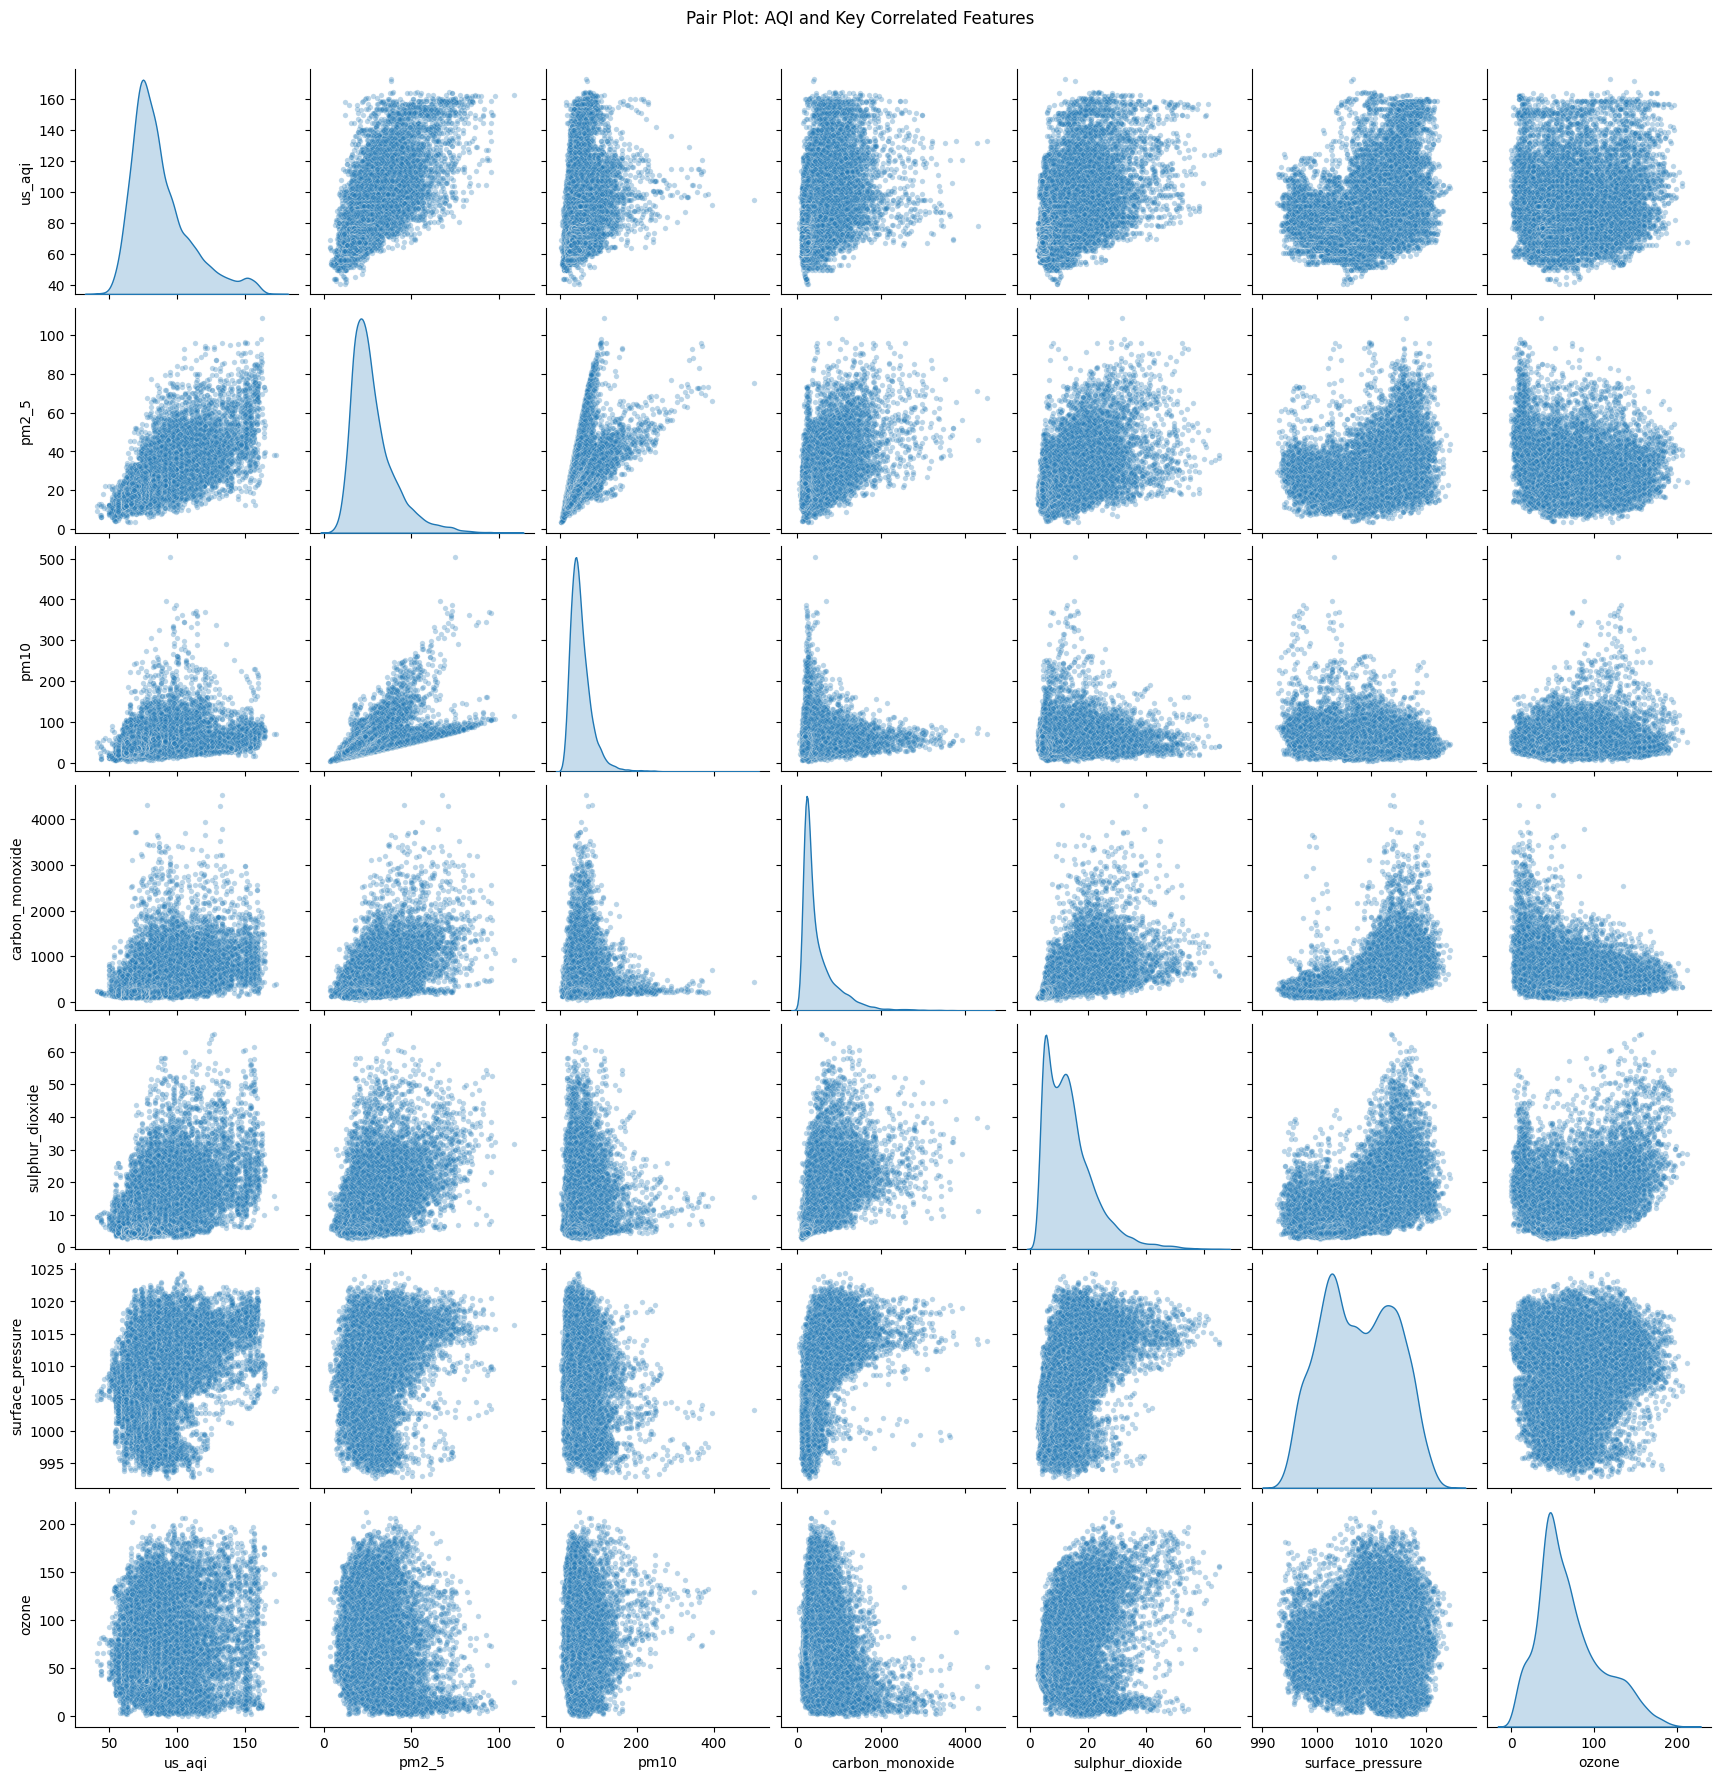

In [85]:
pairplot_cols = [
    "us_aqi",
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "sulphur_dioxide",
    "surface_pressure",
    "ozone"
]

sns.pairplot(
    df[pairplot_cols],
    diag_kind="kde",
    plot_kws={"alpha": 0.3, "s": 15}
)

plt.suptitle("Pair Plot: AQI and Key Correlated Features", y=1.02)
plt.show()

#### Pair Plot Findings:

- `us_aqi` vs `pm2_5` shows a nonlinear (concave) relationship — AQI rises steeply then plateaus at higher PM2.5, consistent with AQI's piecewise-breakpoint calculation rather than a linear scale
- `us_aqi` distribution is bimodal — a dominant peak around 70-90 and a smaller separate cluster near 150-160, suggesting two regimes: normal days vs. severe pollution episodes
- `us_aqi` vs `ozone` confirms the heatmap's near-zero correlation — a pure scattered cloud with no linear or visible nonlinear trend, so ozone alone isn't predictive of AQI
- `pm2_5` vs `pm10` forms a triangular wedge (pm10 always >= pm2_5), consistent with PM10 physically including PM2.5 particles
- `surface_pressure` shows a bimodal distribution (peaks near 1005 and 1013 hPa), suggesting two distinct weather regimes in the dataset
- `carbon_monoxide` and `sulphur_dioxide` remain heavily right-skewed in bivariate view, confirming rare but extreme pollution spikes rather than gradual variation

**Modeling implications:**
- The bimodal AQI distribution means the model needs to capture rare severe-pollution events, not just average conditions — plain regression metrics (RMSE) may undervalue getting these right
- The nonlinear pm2_5-AQI relationship favors tree-based models or nonlinear feature transforms over plain linear regression

### 5. Horizon-wise correlation analysis:
- For each feature at time t, correlate it with us_aqi shifted forward by 24h/48h/72h
- This tells us how predictive power decays as the forecast horizon grows


In [86]:
horizons = {
    "t+24h": 24,
    "t+48h": 48,
    "t+72h": 72
}

feature_cols = [
    "pm2_5", "pm10", "carbon_monoxide", "nitrogen_dioxide",
    "sulphur_dioxide", "ozone", "dust", "us_aqi",
    "temperature_2m", "relative_humidity_2m", "wind_speed_10m",
    "wind_direction_10m", "surface_pressure", "precipitation", "cloud_cover"
]

horizon_corr = pd.DataFrame(index=feature_cols)

for label, shift in horizons.items():
    # shift us_aqi backward so current row aligns feature(t) with aqi(t+shift)
    target = df["us_aqi"].shift(-shift)
    horizon_corr[label] = [df[col].corr(target) for col in feature_cols]

horizon_corr = horizon_corr.round(3)
horizon_corr

,t+24h,t+48h,t+72h
pm2_5,0.736,0.502,0.393
pm10,0.291,0.102,-0.024
carbon_monoxide,0.458,0.381,0.367
nitrogen_dioxide,0.352,0.275,0.265
sulphur_dioxide,0.494,0.391,0.376
ozone,0.152,0.139,0.121
dust,0.023,-0.087,-0.182
us_aqi,0.736,0.552,0.445
temperature_2m,-0.339,-0.334,-0.343
relative_humidity_2m,-0.352,-0.321,-0.307


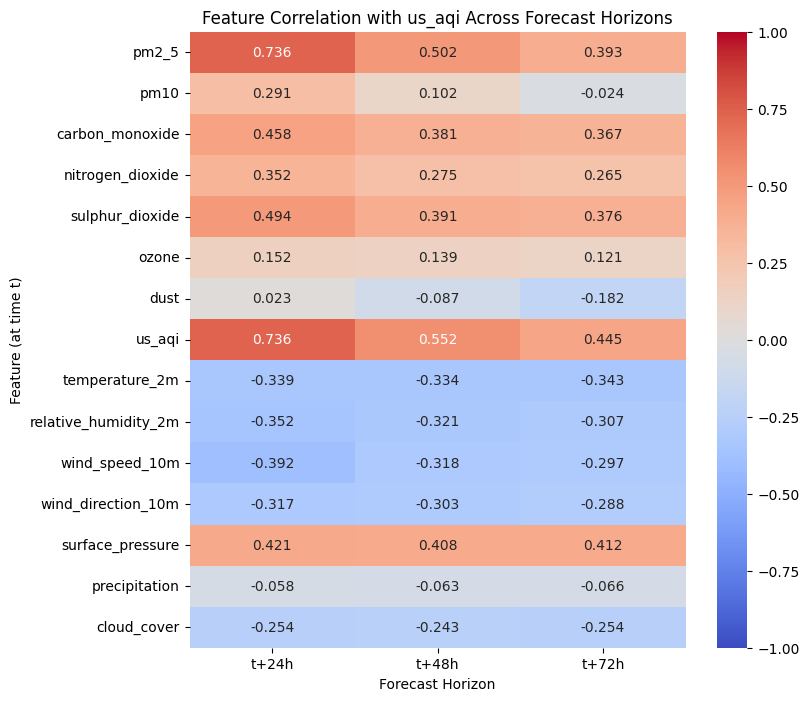

In [87]:
# Visualize as a heatmap for easier comparison across horizons
plt.figure(figsize=(8, 8))

sns.heatmap(
    horizon_corr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Feature Correlation with us_aqi Across Forecast Horizons")
plt.xlabel("Forecast Horizon")
plt.ylabel("Feature (at time t)")
plt.show()

In [88]:
# Quantify the decay explicitly: compare t+0 (current) correlation to each horizon
current_corr = df[feature_cols].corrwith(df["us_aqi"]).round(3)
horizon_corr.insert(0, "t+0h", current_corr)

decay = horizon_corr.copy()
for label in horizons.keys():
    decay[f"{label}_decay_pct"] = (
        (horizon_corr["t+0h"] - horizon_corr[label]) / horizon_corr["t+0h"].abs() * 100
    ).round(1)

decay

,t+0h,t+24h,t+48h,t+72h,t+24h_decay_pct,t+48h_decay_pct,t+72h_decay_pct
pm2_5,0.724,0.736,0.502,0.393,-1.7,30.7,45.7
pm10,0.245,0.291,0.102,-0.024,-18.8,58.4,109.8
carbon_monoxide,0.456,0.458,0.381,0.367,-0.4,16.4,19.5
nitrogen_dioxide,0.365,0.352,0.275,0.265,3.6,24.7,27.4
sulphur_dioxide,0.511,0.494,0.391,0.376,3.3,23.5,26.4
ozone,0.157,0.152,0.139,0.121,3.2,11.5,22.9
dust,-0.020,0.023,-0.087,-0.182,-215.0,335.0,810.0
us_aqi,1.000,0.736,0.552,0.445,26.4,44.8,55.5
temperature_2m,-0.349,-0.339,-0.334,-0.343,-2.9,-4.3,-1.7
relative_humidity_2m,-0.346,-0.352,-0.321,-0.307,1.7,-7.2,-11.3


#### Horizon-Wise Correlation Findings:

- Predictive power decays with horizon, as expected: us_aqi's own autocorrelation drops from 1.00 (t+0) to 0.445 (t+72h), a ~55% relative decay
- pm2_5 remains the strongest external predictor at every horizon, but also decays substantially (0.724 -> 0.393, ~46% by t+72h)
- surface_pressure is the most horizon-robust feature (only ~7% decay by t+72h), staying a moderately strong predictor (r=0.41+) even at 72h out — likely because pressure systems evolve over multi-day timescales
- Gas pollutants (carbon_monoxide, nitrogen_dioxide, sulphur_dioxide) decay more slowly than particulates (16-27% vs 31-46% by t+72h), suggesting they track more persistent regional pollution rather than short-lived spikes
- pm10 becomes unreliable at longer horizons, flipping sign by t+72h (0.245 -> -0.024) — reinforces earlier finding that pm10 is a weak AQI predictor overall
- dust and precipitation show near-zero, unstable correlation at every horizon; their large % decay values are misleading artifacts of dividing by a near-zero baseline

**Modeling implication:**
- Confirms per-horizon modeling is preferable to a single multi-output model: the relative importance of features shifts with horizon (PM2.5/AQI-lag dominate short-term; surface_pressure and gas pollutants matter proportionally more long-term)
- t+24h models should lean heavily on pm2_5 and recent us_aqi lags
- t+72h models should upweight surface_pressure and gas pollutants (CO/NO2/SO2), since these retain signal where PM2.5/PM10/AQI-persistence lose most of theirs

### ACF and PACF Plots:

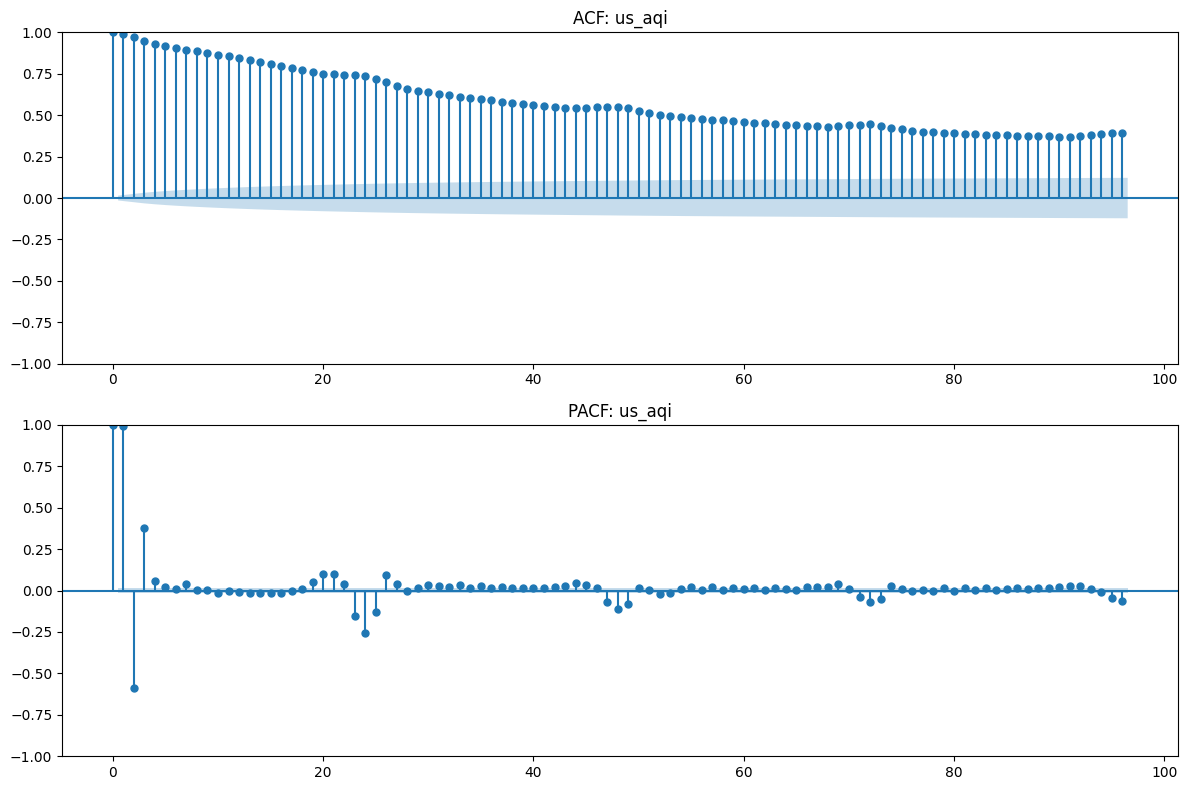

In [89]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df["us_aqi"].dropna(), lags=96, ax=axes[0])  # 96 = 4 days of hourly data
axes[0].set_title("ACF: us_aqi")

plot_pacf(df["us_aqi"].dropna(), lags=96, ax=axes[1], method="ywm")
axes[1].set_title("PACF: us_aqi")

plt.tight_layout()
plt.show()

#### ACF/PACF Findings:

- ACF decays very slowly (still ~0.4 at lag 96), indicating strong long-memory/non-stationary behavior — confirms need for an ADF stationarity test before modeling
- PACF shows a strong short-term AR structure: significant direct effects at lag 1 (~ 1.0), lag 2 (~ -0.60), and lag 3 (~0.38); lags 4-18 are not meaningfully significant on their own
- A secondary cluster of smaller but visible PACF spikes appears around lag 19-26, centered near lag 24 — indicating a genuine daily seasonal effect independent of the short-term AR structure
- This daily pattern echoes faintly at lag ~48 and ~72 (2x and 3x the 24h cycle), with decreasing strength
- These daily-cycle lags (24, 48, 72) coincide exactly with the forecast horizons, supporting their inclusion as direct lag features for each respective horizon model

**Feature engineering implication:**
- Prioritize lag_1, lag_2, lag_3 as the core short-term AR features
- Include lag_24, lag_48, lag_72 to capture daily seasonality — these align naturally with each forecast horizon
- Lags 4-18 (excluding the 24h neighborhood) can likely be dropped without losing much signal

### ADF Test:

In [90]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["us_aqi"].dropna())

print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

if result[1] <= 0.05:
    print("\nSeries is likely STATIONARY (reject null hypothesis)")
else:
    print("\nSeries is likely NON-STATIONARY (fail to reject null hypothesis)")

ADF Statistic: -7.5781
p-value: 0.0000
Critical Values:
   1%: -3.4307
   5%: -2.8617
   10%: -2.5669

Series is likely STATIONARY (reject null hypothesis)


#### ADF Stationarity Test Findings:

- ADF statistic: -7.578, p-value: 0.0000 — well below the 1% critical value (-3.431)
- Series is statistically stationary (reject the null hypothesis of a unit root)
- This appears to contrast with the slow ACF decay, but reflects two different properties:
  the series has no long-term trend/drift (stationary), while still showing strong short-to-medium-term
  persistence/memory (high autocorrelation) — both can be true simultaneously, especially with a large sample size
- No differencing required; proceed to model us_aqi directly using raw values

**Feature engineering implication:**
- Lag features (lag_1, 2, 3, 24, 48, 72) can be built directly on raw us_aqi without needing a differenced version

## Feature Engineering

**Adding new columns for AQI of next 3 days**

In [91]:
df["aqi_t+24h"] = df["us_aqi"].shift(-24)
df["aqi_t+48h"] = df["us_aqi"].shift(-48)
df["aqi_t+72h"] = df["us_aqi"].shift(-72)

df

,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,us_aqi,temperature_2m,relative_humidity_2m,...,month_name,day,day_name,hour,is_weekday,rolling_mean_24h,rolling_std_24h,aqi_t+24h,aqi_t+48h,aqi_t+72h
2024-08-01 00:00:00,20.5,46.8,217.0,14.6,4.6,43.0,42.0,66.0,28.7,88.0,...,August,1,Thursday,0,Weekday,NaN,NaN,74.0,83.0,94.0
2024-08-01 01:00:00,18.9,46.0,180.0,10.5,4.0,45.0,47.0,66.0,28.6,88.0,...,August,1,Thursday,1,Weekday,NaN,NaN,75.0,83.0,94.0
2024-08-01 02:00:00,17.9,46.4,152.0,7.4,3.6,47.0,51.0,66.0,28.6,87.0,...,August,1,Thursday,2,Weekday,NaN,NaN,76.0,83.0,94.0
2024-08-01 03:00:00,17.2,47.1,136.0,5.8,3.4,48.0,53.0,66.0,28.7,85.0,...,August,1,Thursday,3,Weekday,NaN,NaN,76.0,83.0,94.0
2024-08-01 04:00:00,16.9,47.1,128.0,5.1,3.5,48.0,53.0,66.0,28.6,85.0,...,August,1,Thursday,4,Weekday,NaN,NaN,77.0,84.0,94.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-22 17:00:00,20.3,47.7,250.0,7.6,4.3,50.0,39.0,68.0,28.3,76.0,...,August,22,Saturday,17,Weekend,65.666667,1.632993,NaN,NaN,NaN
2026-08-22 18:00:00,20.4,47.3,256.0,9.1,4.4,47.0,35.0,68.0,27.9,79.0,...,August,22,Saturday,18,Weekend,65.875000,1.596532,NaN,NaN,NaN
2026-08-22 19:00:00,20.2,44.6,255.0,10.6,4.4,44.0,31.0,68.0,27.3,83.0,...,August,22,Saturday,19,Weekend,66.083333,1.529895,NaN,NaN,NaN
2026-08-22 20:00:00,17.3,38.0,250.0,11.5,4.5,42.0,29.0,68.0,27.1,85.0,...,August,22,Saturday,20,Weekend,66.291667,1.428869,NaN,NaN,NaN


**Creating lag columns**

Based on the PACF findings, we create lag features using only the lags that showed genuine direct predictive value, rather than adding every possible lag blindly:

- **Short-term AR lags (1, 2, 3):** capture the immediate hour-to-hour momentum of AQI, which PACF showed as strong, direct, non-redundant effects (lag 1 ≈ 1.0, lag 2 ≈ -0.60, lag 3 ≈ 0.38)
- **Daily seasonality lags (24, 48, 72):** capture the recurring "same hour, previous day(s)" pattern identified from the PACF spikes clustered around lag 24 — these also conveniently align with our three forecast horizons (t+24h, t+48h, t+72h)
- Intermediate lags (4–18) were excluded, since PACF showed no meaningful direct effect once lags 1–3 are already accounted for

The ADF test confirmed `us_aqi` is stationary, so lags are built directly on the raw series without any differencing.


In [92]:
for lag in [1, 2, 3, 24, 48, 72]:
    df[f"us_aqi_lag{lag}"] = df["us_aqi"].shift(lag)

df[["us_aqi", "us_aqi_lag1", "us_aqi_lag2", "us_aqi_lag3",
    "us_aqi_lag24", "us_aqi_lag48", "us_aqi_lag72"]].head(73)

,us_aqi,us_aqi_lag1,us_aqi_lag2,us_aqi_lag3,us_aqi_lag24,us_aqi_lag48,us_aqi_lag72
2024-08-01 00:00:00,66.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-08-01 01:00:00,66.0,66.0,NaN,NaN,NaN,NaN,NaN
2024-08-01 02:00:00,66.0,66.0,66.0,NaN,NaN,NaN,NaN
2024-08-01 03:00:00,66.0,66.0,66.0,66.0,NaN,NaN,NaN
2024-08-01 04:00:00,66.0,66.0,66.0,66.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2024-08-03 20:00:00,93.0,93.0,93.0,92.0,84.0,71.0,NaN
2024-08-03 21:00:00,93.0,93.0,93.0,93.0,84.0,72.0,NaN
2024-08-03 22:00:00,93.0,93.0,93.0,93.0,84.0,73.0,NaN
2024-08-03 23:00:00,94.0,93.0,93.0,93.0,83.0,73.0,NaN


### Cyclic Encoding

Several time and directional features are naturally cyclic — the raw integer encoding treats
hour 23 and hour 0 as far apart, when they're actually adjacent. Sin/cos encoding preserves this
circular closeness by mapping each value onto a unit circle.

Applied to:
- **hour** (0–23) — daily cycle, e.g. hour 23 and hour 0 are adjacent
- **day_of_week** (0–6, Monday=0) — weekly cycle, e.g. Sunday and Monday are adjacent
- **month** (0–11) — yearly/seasonal cycle, e.g. December and January are adjacent
- **wind_direction_10m** (0–360°) — compass direction, e.g. 359° and 0° point the same way

Each feature is converted to sin/cos pairs to give the model both the position on the cycle
and enough information to distinguish otherwise-identical sin (or cos) values:

`feature_sin = sin(2π * value / period)`
`feature_cos = cos(2π * value / period)`

where `period` is the natural cycle length (24 for hour, 7 for day of week, 12 for month,
360 for wind direction).

Raw categorical columns (`day_name`, `month_name`) were first mapped to numeric codes before
encoding. Raw versions are retained alongside the cyclic ones — useful for tree-based models,
which can use either; only linear/distance-based models would need the raw versions dropped
to avoid the discontinuity issue cyclic encoding solves.

In [93]:
day_name = {"monday":0,"tuesday":1,"wednesday":2,"thursday":3,"friday":4,"saturday":5,"sunday":6}
df["day_name"] = df["day_name"].str.lower().replace(day_name)

month_name = {'August':7, 'September':8, 'October':9, 'November':10, 'December':11,
       'January':0, 'February':1, 'March':2, 'April':3, 'May':4, 'June':5, 'July':6}
df["month_name"] = df["month_name"].replace(month_name)

/tmp/ipykernel_1131/3537657420.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["day_name"] = df["day_name"].str.lower().replace(day_name)
/tmp/ipykernel_1131/3537657420.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["month_name"] = df["month_name"].replace(month_name)


In [94]:
df["day_of_week_sin"] = np.sin(2 * np.pi * df["day_name"] / 7)
df["day_of_week_cos"] = np.cos(2 * np.pi * df["day_name"] / 7)

df["month_sin"] = np.sin(2 * np.pi * df["month_name"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month_name"] / 12)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["wind_direction_10m_sin"] = np.sin(2 * np.pi * df["wind_direction_10m"] / 360)
df["wind_direction_10m_cos"] = np.cos(2 * np.pi * df["wind_direction_10m"] / 360)

df[["day_of_week_sin","day_of_week_cos","month_sin","month_cos","hour_sin","hour_cos","wind_direction_10m_sin","wind_direction_10m_cos"]]

,day_of_week_sin,day_of_week_cos,month_sin,month_cos,hour_sin,hour_cos,wind_direction_10m_sin,wind_direction_10m_cos
2024-08-01 00:00:00,0.433884,-0.900969,-0.5,-0.866025,0.000000,1.000000e+00,-0.819152,-0.573576
2024-08-01 01:00:00,0.433884,-0.900969,-0.5,-0.866025,0.258819,9.659258e-01,-0.866025,-0.500000
2024-08-01 02:00:00,0.433884,-0.900969,-0.5,-0.866025,0.500000,8.660254e-01,-0.906308,-0.422618
2024-08-01 03:00:00,0.433884,-0.900969,-0.5,-0.866025,0.707107,7.071068e-01,-0.933580,-0.358368
2024-08-01 04:00:00,0.433884,-0.900969,-0.5,-0.866025,0.866025,5.000000e-01,-0.961262,-0.275637
...,...,...,...,...,...,...,...,...
2026-08-22 17:00:00,-0.974928,-0.222521,-0.5,-0.866025,-0.965926,-2.588190e-01,-0.777146,-0.629320
2026-08-22 18:00:00,-0.974928,-0.222521,-0.5,-0.866025,-1.000000,-1.836970e-16,-0.766044,-0.642788
2026-08-22 19:00:00,-0.974928,-0.222521,-0.5,-0.866025,-0.965926,2.588190e-01,-0.766044,-0.642788
2026-08-22 20:00:00,-0.974928,-0.222521,-0.5,-0.866025,-0.866025,5.000000e-01,-0.788011,-0.615661


**Converting `is_weekday` column into int (0/1)**

In [95]:
df["is_weekday"] = df["is_weekday"].replace({"Weekday":1,"Weekend":0})
df["is_weekday"].unique()

/tmp/ipykernel_1131/3557960150.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["is_weekday"] = df["is_weekday"].replace({"Weekday":1,"Weekend":0})


array([1, 0])

#### Checking for NAN values:
- these null values are caused by using rolling mean/std, laggings and making the target columns.
- at the start of dataset there 72 and at the end there 72 NAN containing rows, in total 144 which a very small number compared to our dataset so we will drop them and dropping them wont cause any problem because they are contiguous at the edge of the dataset but before dropping them we will also check that there are 144 NAN containing rows for confirmation.  

In [96]:
print(f"Numbers of NAN containing rows: {df[df.isna().any(axis=1)].shape[0]}")
print(f"Percent of NAN containing rows: {round(df[df.isna().any(axis=1)].shape[0]*100/len(df),3)}%")


Numbers of NAN containing rows: 144
Percent of NAN containing rows: 0.798%


- We confirmed that there is no other NAN containing rows so now we will just drop them.

In [97]:
df.dropna(axis=0,inplace=True)
df.shape

(17902, 40)

## Train/Val/Test Split:

In [98]:
min_date = df.index.min()
max_date = df.index.max()

train_split = ((max_date - min_date)*0.7 + min_date).floor("h")
val_split = ((max_date - min_date)*0.85 + min_date).floor("h")

train = df.loc[:train_split]
val = df.loc[train_split+pd.Timedelta(hours=1):val_split]
test = df.loc[val_split+pd.Timedelta(hours=1):]

print(f"Train: {train.index.min()} to {train.index.max()} ({len(train)} rows)")
print(f"Val:   {val.index.min()} to {val.index.max()} ({len(val)} rows)")
print(f"Test:  {test.index.min()} to {test.index.max()} ({len(test)} rows)")

total = len(df)
print(f"\nTrain %: {len(train)/total:.1%}")
print(f"Val %:   {len(val)/total:.1%}")
print(f"Test %:  {len(test)/total:.1%}")

Train: 2024-08-04 00:00:00 to 2026-01-08 02:00:00 (12531 rows)
Val:   2026-01-08 03:00:00 to 2026-04-29 23:00:00 (2685 rows)
Test:  2026-04-30 00:00:00 to 2026-08-19 21:00:00 (2686 rows)

Train %: 70.0%
Val %:   15.0%
Test %:  15.0%


#### Scaling columns

In [99]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = [
    "pm2_5", "pm10", "carbon_monoxide", "nitrogen_dioxide", "sulphur_dioxide",
    "ozone", "dust", "us_aqi", "temperature_2m", "relative_humidity_2m",
    "wind_speed_10m", "wind_direction_10m", "surface_pressure", "precipitation",
    "cloud_cover", "rolling_mean_24h", "rolling_std_24h",
    "us_aqi_lag1", "us_aqi_lag2", "us_aqi_lag3",
    "us_aqi_lag24", "us_aqi_lag48", "us_aqi_lag72"
]

scaler = StandardScaler()

train_scaled = train.copy()
val_scaled = val.copy()
test_scaled = test.copy()

train_scaled[cols_to_scale] = scaler.fit_transform(train[cols_to_scale])
val_scaled[cols_to_scale] = scaler.transform(val[cols_to_scale])
test_scaled[cols_to_scale] = scaler.transform(test[cols_to_scale])

## Model Training:

- We will drop `dust` for high correlation with `pm10` so it wont cause multicollinearlity.We will do this for all models except for tree-based models because this doesnt do any harm to them.

In [100]:
drop_col = ['wind_direction_10m','city','month_name','day', 'day_name', 'hour','aqi_t+24h', 'aqi_t+48h',
       'aqi_t+72h']

X_train = train_scaled.drop(columns=drop_col+['dust'])
X_val = val_scaled.drop(columns=drop_col+['dust'])
X_test = test_scaled.drop(columns=drop_col+['dust'])

In [101]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12531 entries, 2024-08-04 00:00:00 to 2026-01-08 02:00:00
Freq: h
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   pm2_5                   12531 non-null  float64
 1   pm10                    12531 non-null  float64
 2   carbon_monoxide         12531 non-null  float64
 3   nitrogen_dioxide        12531 non-null  float64
 4   sulphur_dioxide         12531 non-null  float64
 5   ozone                   12531 non-null  float64
 6   us_aqi                  12531 non-null  float64
 7   temperature_2m          12531 non-null  float64
 8   relative_humidity_2m    12531 non-null  float64
 9   wind_speed_10m          12531 non-null  float64
 10  surface_pressure        12531 non-null  float64
 11  precipitation           12531 non-null  float64
 12  cloud_cover             12531 non-null  float64
 13  is_weekday              12531 non-null  int64  


### 1. Ridge Regression:

In [102]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
horizons = ["aqi_t+24h", "aqi_t+48h", "aqi_t+72h"]
alphas = [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0, 5000.0, 10000.0]

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

# ------------------------------------------------------------
# Train + evaluate every alpha for every horizon
# ------------------------------------------------------------
all_results = []

for horizon in horizons:
    y_train = train_scaled[horizon]
    y_val = val_scaled[horizon]

    for alpha in alphas:
        model = Ridge(alpha=alpha)
        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)

        train_mae = mean_absolute_error(y_train, train_pred)
        val_mae = mean_absolute_error(y_val, val_pred)
        train_rmse = rmse(y_train, train_pred)
        val_rmse = rmse(y_val, val_pred)
        train_r2 = r2_score(y_train, train_pred)
        val_r2 = r2_score(y_val, val_pred)

        all_results.append({
            "horizon": horizon,
            "alpha": alpha,
            "train_mae": train_mae, "val_mae": val_mae, "mae_gap": val_mae - train_mae,
            "train_rmse": train_rmse, "val_rmse": val_rmse, "rmse_gap": val_rmse - train_rmse,
            "train_r2": train_r2, "val_r2": val_r2, "r2_gap": train_r2 - val_r2
        })

results_df = pd.DataFrame(all_results)
results_df

,horizon,alpha,train_mae,val_mae,mae_gap,train_rmse,val_rmse,rmse_gap,train_r2,val_r2,r2_gap
0,aqi_t+24h,0.01,8.823395,10.767645,1.944250,12.592210,14.520268,1.928058,0.713331,0.439062,0.274269
1,aqi_t+24h,0.10,8.823412,10.767541,1.944129,12.592210,14.520133,1.927923,0.713330,0.439072,0.274259
2,aqi_t+24h,1.00,8.823571,10.766521,1.942951,12.592224,14.518811,1.926588,0.713330,0.439174,0.274156
3,aqi_t+24h,10.00,8.825188,10.757405,1.932218,12.592895,14.507378,1.914483,0.713299,0.440057,0.273242
4,aqi_t+24h,50.00,8.833364,10.727124,1.893760,12.598616,14.471082,1.872467,0.713039,0.442855,0.270183
5,aqi_t+24h,100.00,8.845131,10.702754,1.857623,12.609058,14.441308,1.832249,0.712563,0.445146,0.267417
6,aqi_t+24h,500.00,8.958793,10.667660,1.708867,12.730802,14.386379,1.655577,0.706986,0.449359,0.257627
7,aqi_t+24h,1000.00,9.092061,10.710937,1.618876,12.881395,14.419120,1.537725,0.700012,0.446849,0.253163
8,aqi_t+24h,5000.00,9.694398,11.036708,1.342310,13.564801,14.656379,1.091578,0.667337,0.428496,0.238841
9,aqi_t+24h,10000.00,10.114286,11.245480,1.131194,13.993961,14.794992,0.801032,0.645955,0.417635,0.228320


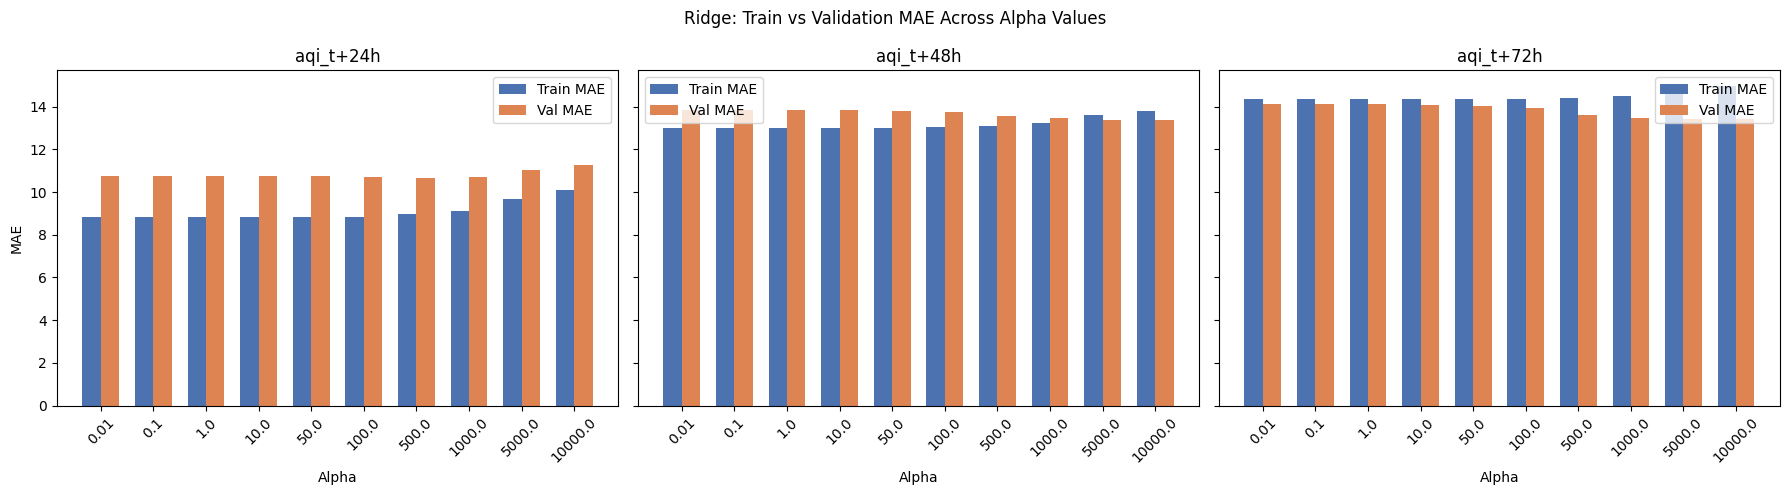

In [103]:
# ------------------------------------------------------------
# Plot: Train vs Val MAE per alpha, one subplot per horizon
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, horizon in zip(axes, horizons):
    subset = results_df[results_df["horizon"] == horizon]
    x = np.arange(len(alphas))
    width = 0.35

    ax.bar(x - width/2, subset["train_mae"], width, label="Train MAE", color="#4C72B0")
    ax.bar(x + width/2, subset["val_mae"], width, label="Val MAE", color="#DD8452")

    ax.set_xticks(x)
    ax.set_xticklabels(alphas, rotation=45)
    ax.set_xlabel("Alpha")
    ax.set_title(horizon)
    ax.legend()

axes[0].set_ylabel("MAE")
plt.suptitle("Ridge: Train vs Validation MAE Across Alpha Values")
plt.tight_layout()
plt.show()

In [104]:
# ------------------------------------------------------------
# Select best alpha per horizon (lowest val MAE) and fit final models
# ------------------------------------------------------------
ridge_models = {}
ridge_best = {}

for horizon in horizons:
    subset = results_df[results_df["horizon"] == horizon]
    best = subset.loc[subset["val_mae"].idxmin()]
    ridge_best[horizon] = best

    final_model = Ridge(alpha=best["alpha"])
    final_model.fit(X_train, train[horizon])
    ridge_models[horizon] = final_model

    print(f"{horizon}: best alpha={best['alpha']}, "
          f"val MAE={best['val_mae']:.3f}, val RMSE={best['val_rmse']:.3f}, "
          f"val R²={best['val_r2']:.3f}, MAE gap={best['mae_gap']:.3f}")

aqi_t+24h: best alpha=500.0, val MAE=10.668, val RMSE=14.386, val R²=0.449, MAE gap=1.709
aqi_t+48h: best alpha=10000.0, val MAE=13.381, val RMSE=17.298, val R²=0.205, MAE gap=-0.431
aqi_t+72h: best alpha=5000.0, val MAE=13.402, val RMSE=17.387, val R²=0.194, MAE gap=-1.402


In [105]:
test_results = {}

for horizon in horizons:
    y_test = test[horizon]
    model = ridge_models[horizon]  # already fit on train using each horizon's best alpha
    test_pred = model.predict(X_test)

    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = rmse(y_test, test_pred)
    test_r2 = r2_score(y_test, test_pred)

    test_results[horizon] = {"mae": test_mae, "rmse": test_rmse, "r2": test_r2}

    print(f"{horizon} — Test MAE: {test_mae:.3f}, Test RMSE: {test_rmse:.3f}, Test R²: {test_r2:.3f}")

aqi_t+24h — Test MAE: 5.415, Test RMSE: 7.830, Test R²: 0.534
aqi_t+48h — Test MAE: 7.646, Test RMSE: 10.823, Test R²: 0.124
aqi_t+72h — Test MAE: 8.284, Test RMSE: 11.755, Test R²: -0.028


In [106]:
comparison = pd.DataFrame({
    "horizon": horizons,
    "val_mae": [ridge_best[h]["val_mae"] for h in horizons],
    "test_mae": [test_results[h]["mae"] for h in horizons],
    "val_rmse": [ridge_best[h]["val_rmse"] for h in horizons],
    "test_rmse": [test_results[h]["rmse"] for h in horizons],
    "val_r2": [ridge_best[h]["val_r2"] for h in horizons],
    "test_r2": [test_results[h]["r2"] for h in horizons],
})

comparison

,horizon,val_mae,test_mae,val_rmse,test_rmse,val_r2,test_r2
0,aqi_t+24h,10.667660,5.415465,14.386379,7.829624,0.449359,0.533713
1,aqi_t+48h,13.381015,7.645529,17.297615,10.823290,0.204705,0.124198
2,aqi_t+72h,13.401521,8.284328,17.386674,11.754682,0.193930,-0.028011


In [107]:
persistence_results = {}

for horizon in horizons:
    y_test = test[horizon]
    persistence_pred = test["us_aqi"]  # today's value used as the "prediction" for the future

    persistence_results[horizon] = {
        "mae": mean_absolute_error(y_test, persistence_pred),
        "rmse": rmse(y_test, persistence_pred),
        "r2": r2_score(y_test, persistence_pred)
    }
    print(f"{horizon} (persistence) — MAE: {persistence_results[horizon]['mae']:.3f}, "
          f"RMSE: {persistence_results[horizon]['rmse']:.3f}, "
          f"R²: {persistence_results[horizon]['r2']:.3f}")

aqi_t+24h (persistence) — MAE: 6.432, RMSE: 9.352, R²: 0.335
aqi_t+48h (persistence) — MAE: 9.287, RMSE: 13.123, R²: -0.287
aqi_t+72h (persistence) — MAE: 10.672, RMSE: 15.260, R²: -0.733


In [108]:
for horizon in horizons:
    model_rmse = test_results[horizon]["rmse"]  # or ridge/nn
    persist_rmse = persistence_results[horizon]["rmse"]
    improvement = (model_rmse - persist_rmse) / persist_rmse * 100
    print(f"{horizon}: {improvement:.1f}% RMSE vs persistence")

aqi_t+24h: -16.3% RMSE vs persistence
aqi_t+48h: -17.5% RMSE vs persistence
aqi_t+72h: -23.0% RMSE vs persistence


#### Ridge Regression: Final Conclusion

**Val vs Test performance**

| Horizon | Val MAE | Test MAE | Val RMSE | Test RMSE | Val R² | Test R² |
|---------|---------|----------|----------|-----------|--------|---------|
| t+24h   | 10.668  | 5.415    | 14.386   | 7.830     | 0.449  | 0.534   |
| t+48h   | 13.381  | 7.646    | 17.298   | 10.823    | 0.205  | 0.124   |
| t+72h   | 13.402  | 8.284    | 17.387   | 11.755    | 0.194  | -0.028  |

**Test error is lower than val error across every horizon** (e.g. t+24h MAE: 10.7 → 5.4), suggesting
the test period contains less volatile or lower-magnitude AQI values than the validation period,
rather than the model performing better on genuinely unseen data. R² tells the more reliable story
here, since it's normalized against the target's own variance in that period rather than raw error
magnitude.

**Horizon-wise degradation is confirmed on test data, and gets worse than validation suggested:**
- **t+24h**: R²=0.534 — the model explains just over half the variance in next-day AQI. The strongest
  result from Ridge.
- **t+48h**: R² drops to 0.124 — the model explains little more than a tenth of the variance, a sharp
  decline consistent with the horizon-correlation and PACF findings from EDA.
- **t+72h**: R² is **negative (-0.028)** — Ridge performs *worse than the test set's own mean* at
  this horizon, meaning it captures none of the period-specific variance in AQI.

**Improvement over persistence baseline**: Despite the weak/negative R² at longer horizons, Ridge
still meaningfully outperforms the naive persistence baseline (predicting no change from current
AQI) at every horizon:

| Horizon | Ridge RMSE Improvement vs Persistence |
|---------|------------------------------------------|
| t+24h   | -16.3%                                     |
| t+48h   | -17.5%                                     |
| t+72h   | -23.0%                                     |

This is an important distinction: **R²=-0.028 at t+72h does not mean Ridge has no predictive value** —
it means Ridge doesn't capture much of the test period's own AQI variance, which itself is small at
that point (persistence's R² at t+72h is -0.733, far worse). Relative to a naive forecast, Ridge is
still adding real value, particularly at longer horizons where persistence degrades faster than Ridge
does.

**Overall assessment**: Ridge provides its strongest result at the 24-hour horizon (R²=0.534) and
weakens substantially beyond that in absolute terms. However, it consistently and increasingly
outperforms naive persistence forecasting at every horizon, confirming it captures genuine, if
limited, predictive signal even at 72h. This is consistent with two earlier findings: (1) the pair
plot showed a nonlinear (concave) relationship between pm2_5 and us_aqi that a linear model cannot
fully represent, and (2) horizon-wise correlation showed most features' predictive power decaying
substantially by 48-72h.

**This motivates testing nonlinear models** as the next step — specifically to check whether they
can recover additional predictive power at the 48h and 72h horizons beyond what Ridge already
captures, and whether tree-based/nonlinear methods handle the concave pm2_5-AQI relationship (and
similar patterns in other features) better than a straight-line fit.

### 2. Random Forest

In [109]:
X_train_rf = train.drop(columns=drop_col)
X_val_rf = val.drop(columns=drop_col)
X_test_rf = test.drop(columns=drop_col)

In [126]:
from sklearn.ensemble import RandomForestRegressor

horizons = ["aqi_t+24h", "aqi_t+48h", "aqi_t+72h"]

# Set A: tree-based feature set — no scaling, raw + cyclic columns can coexist
# (X_train, X_val, X_test — the un-scaled versions you built earlier for RF)

rf_models = {}
rf_results = []

for horizon in horizons:
    y_train = train_scaled[horizon]
    y_val = val_scaled[horizon]

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=20,
        min_samples_split=50,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train_rf, y_train)

    train_pred = model.predict(X_train_rf)
    val_pred = model.predict(X_val_rf)

    train_mae = mean_absolute_error(y_train, train_pred)
    val_mae = mean_absolute_error(y_val, val_pred)
    train_rmse = rmse(y_train, train_pred)
    val_rmse = rmse(y_val, val_pred)
    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_val, val_pred)

    rf_models[horizon] = model
    rf_results.append({
        "horizon": horizon,
        "train_mae": train_mae, "val_mae": val_mae, "mae_gap": val_mae - train_mae,
        "train_rmse": train_rmse, "val_rmse": val_rmse,
        "train_r2": train_r2, "val_r2": val_r2, "r2_gap": train_r2 - val_r2
    })

    print(f"{horizon}: train MAE={train_mae:.3f}, val MAE={val_mae:.3f}, gap={val_mae-train_mae:.3f}, "
          f"train R²={train_r2:.3f}, val R²={val_r2:.3f}")

rf_results_df = pd.DataFrame(rf_results)
rf_results_df


aqi_t+24h: train MAE=7.040, val MAE=10.820, gap=3.781, train R²=0.813, val R²=0.433
aqi_t+48h: train MAE=9.334, val MAE=13.099, gap=3.765, train R²=0.706, val R²=0.177
aqi_t+72h: train MAE=9.797, val MAE=13.355, gap=3.557, train R²=0.689, val R²=0.153


,horizon,train_mae,val_mae,mae_gap,train_rmse,val_rmse,train_r2,val_r2,r2_gap
0,aqi_t+24h,7.039655,10.820194,3.780540,10.171084,14.592804,0.812970,0.433443,0.379526
1,aqi_t+48h,9.333871,13.098903,3.765032,12.754187,17.600086,0.705947,0.176648,0.529299
2,aqi_t+72h,9.797258,13.354676,3.557418,13.113622,17.818505,0.689181,0.153392,0.535789


In [127]:
rf_test_results = {}

for horizon in horizons:
    y_test = test[horizon]
    model = rf_models[horizon]
    test_pred = model.predict(X_test_rf)

    rf_test_results[horizon] = {
        "mae": mean_absolute_error(y_test, test_pred),
        "rmse": rmse(y_test, test_pred),
        "r2": r2_score(y_test, test_pred)
    }
    print(f"{horizon} — Test MAE: {rf_test_results[horizon]['mae']:.3f}, "
          f"Test RMSE: {rf_test_results[horizon]['rmse']:.3f}, "
          f"Test R²: {rf_test_results[horizon]['r2']:.3f}")

aqi_t+24h — Test MAE: 5.412, Test RMSE: 7.743, Test R²: 0.544
aqi_t+48h — Test MAE: 7.395, Test RMSE: 10.641, Test R²: 0.153
aqi_t+72h — Test MAE: 7.462, Test RMSE: 11.306, Test R²: 0.049


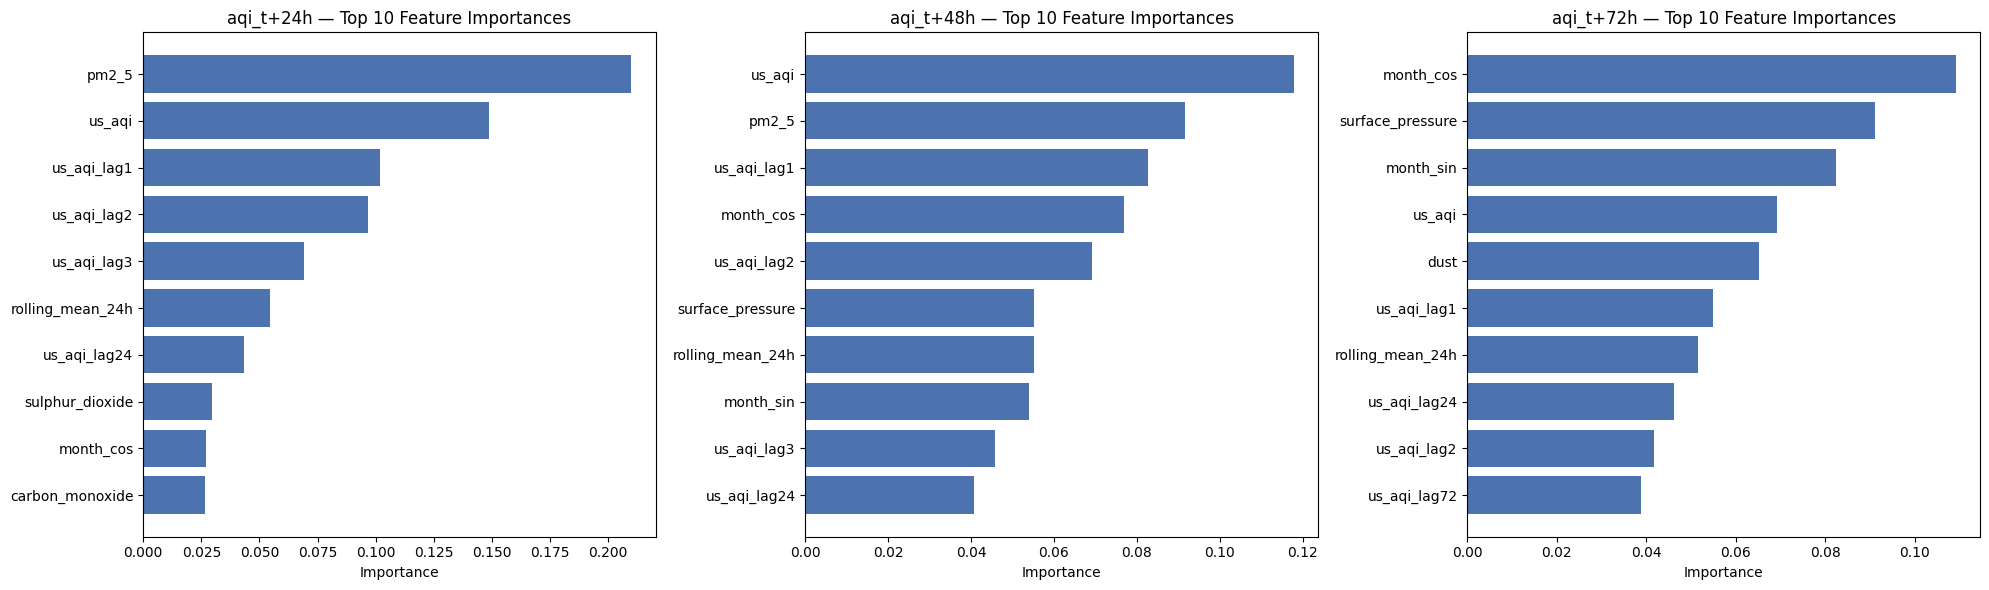

In [112]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, horizon in zip(axes, horizons):
    model = rf_models[horizon]
    importances = pd.Series(model.feature_importances_, index=X_train_rf.columns)
    top10 = importances.sort_values(ascending=False).head(10)

    ax.barh(top10.index[::-1], top10.values[::-1], color="#4C72B0")
    ax.set_title(f"{horizon} — Top 10 Feature Importances")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

In [113]:
persistence_results = {}

for horizon in horizons:
    y_test = test[horizon]
    persistence_pred = test["us_aqi"]  # today's value used as the "prediction" for the future

    persistence_results[horizon] = {
        "mae": mean_absolute_error(y_test, persistence_pred),
        "rmse": rmse(y_test, persistence_pred),
        "r2": r2_score(y_test, persistence_pred)
    }
    print(f"{horizon} (persistence) — MAE: {persistence_results[horizon]['mae']:.3f}, "
          f"RMSE: {persistence_results[horizon]['rmse']:.3f}, "
          f"R²: {persistence_results[horizon]['r2']:.3f}")

aqi_t+24h (persistence) — MAE: 6.432, RMSE: 9.352, R²: 0.335
aqi_t+48h (persistence) — MAE: 9.287, RMSE: 13.123, R²: -0.287
aqi_t+72h (persistence) — MAE: 10.672, RMSE: 15.260, R²: -0.733


In [114]:
for horizon in horizons:
    model_rmse = rf_test_results[horizon]["rmse"]  # or ridge/nn
    persist_rmse = persistence_results[horizon]["rmse"]
    improvement = (model_rmse - persist_rmse) / persist_rmse * 100
    print(f"{horizon}: {improvement:.1f}% RMSE vs persistence")

aqi_t+24h: -17.2% RMSE vs persistence
aqi_t+48h: -18.9% RMSE vs persistence
aqi_t+72h: -25.9% RMSE vs persistence


#### Random Forest: Final Conclusion

**Test performance vs Ridge**

| Horizon | Ridge Test R² | RF Test R² | RF RMSE vs Persistence |
|---------|---------------|------------|--------------------------|
| t+24h   | 0.534         | 0.544      | -17.2%                    |
| t+48h   | 0.124         | 0.154      | -18.9%                    |
| t+72h   | -0.028        | 0.049      | -25.9%                    |

RF outperforms Ridge at every horizon, with the gap widest at t+72h — where Ridge fails outright
(negative R²) but RF still beats naive persistence by 25.9%. This supports the pair plot's finding
of a nonlinear pm2_5-AQI relationship, which a tree-based model can partially capture.

**Overfitting check**: train/val MAE gap approx. 3.6-3.8, train R² 0.69-0.81 — a controlled fit after
regularizing (max_depth=8, min_samples_leaf=20-30, max_features="sqrt"); an earlier unconstrained
version had memorized train data almost completely (train R²~0.96, negative val R²).

**Feature importance**: `pm2_5`/`us_aqi` lags dominate at t+24h; `surface_pressure` and
`month_cos`/`sin` rise in importance by t+72h. Note: val (Jan-Apr) and test (Apr-Aug) cover only
partial, non-overlapping seasons, so month's importance may be partly a split-membership artifact
rather than pure seasonality — a limitation of the current split, not the model.

**Conclusion**: RF is the strongest model so far, beating both Ridge and persistence at every
horizon, with growing relative advantage at longer horizons. It's the current leading candidate for
the final deployed model, pending comparison against the Neural Network.

### 3. Neural Network:

In [132]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

horizons = ["aqi_t+24h", "aqi_t+48h", "aqi_t+72h"]

# Uses the SAME scaled feature set as Ridge (X_train, X_val, X_test)
# since NNs are gradient/distance-sensitive, just like linear models

nn_models = {}
nn_histories = {}
nn_results = []

for horizon in horizons:
    y_train = train_scaled[horizon].values
    y_val = val_scaled[horizon].values

    tf.random.set_seed(42)

    model = models.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.1),
        layers.Dense(1)  # single regression output
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mae",
        metrics=["mae"]
    )

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=64,
        callbacks=[early_stop],
        verbose=0
    )

    train_pred = model.predict(X_train, verbose=0).flatten()
    val_pred = model.predict(X_val, verbose=0).flatten()

    train_mae = mean_absolute_error(y_train, train_pred)
    val_mae = mean_absolute_error(y_val, val_pred)
    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_val, val_pred)

    nn_models[horizon] = model
    nn_histories[horizon] = history
    nn_results.append({
        "horizon": horizon, "train_mae": train_mae, "val_mae": val_mae,
        "mae_gap": val_mae - train_mae, "train_r2": train_r2, "val_r2": val_r2,
        "epochs_trained": len(history.history["loss"])
    })

    print(f"{horizon}: train MAE={train_mae:.3f}, val MAE={val_mae:.3f}, gap={val_mae-train_mae:.3f}, "
          f"train R²={train_r2:.3f}, val R²={val_r2:.3f}, stopped at epoch {len(history.history['loss'])}")

nn_results_df = pd.DataFrame(nn_results)
nn_results_df

aqi_t+24h: train MAE=8.022, val MAE=10.544, gap=2.522, train R²=0.746, val R²=0.426, stopped at epoch 28
aqi_t+48h: train MAE=11.005, val MAE=13.986, gap=2.981, train R²=0.546, val R²=0.003, stopped at epoch 30
aqi_t+72h: train MAE=12.759, val MAE=14.176, gap=1.417, train R²=0.413, val R²=-0.051, stopped at epoch 20


,horizon,train_mae,val_mae,mae_gap,train_r2,val_r2,epochs_trained
0,aqi_t+24h,8.021576,10.543631,2.522055,0.746211,0.426495,28
1,aqi_t+48h,11.005088,13.986316,2.981229,0.545589,0.002903,30
2,aqi_t+72h,12.759403,14.176218,1.416815,0.412893,-0.051275,20


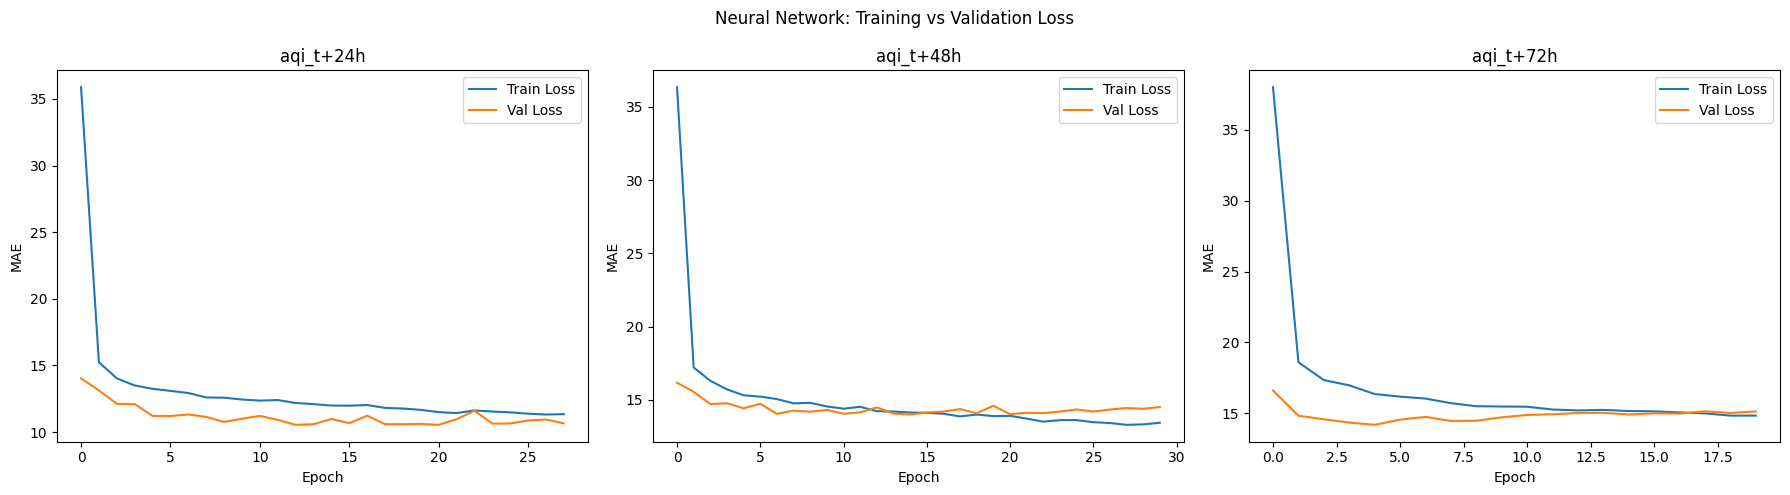

In [138]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, horizon in zip(axes, horizons):
    history = nn_histories[horizon]
    ax.plot(history.history["loss"], label="Train Loss")
    ax.plot(history.history["val_loss"], label="Val Loss")
    ax.set_title(horizon)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE")
    ax.legend()

plt.suptitle("Neural Network: Training vs Validation Loss")
plt.tight_layout()
plt.show()

In [135]:
nn_test_results = {}

for horizon in horizons:
    y_test = test[horizon].values
    model = nn_models[horizon]
    test_pred = model.predict(X_test, verbose=0).flatten()

    nn_test_results[horizon] = {
        "mae": mean_absolute_error(y_test, test_pred),
        "rmse": rmse(y_test, test_pred),
        "r2": r2_score(y_test, test_pred)
    }
    print(f"{horizon} — Test MAE: {nn_test_results[horizon]['mae']:.3f}, "
          f"Test RMSE: {nn_test_results[horizon]['rmse']:.3f}, "
          f"Test R²: {nn_test_results[horizon]['r2']:.3f}")

aqi_t+24h — Test MAE: 5.307, Test RMSE: 7.803, Test R²: 0.537
aqi_t+48h — Test MAE: 7.524, Test RMSE: 11.133, Test R²: 0.073
aqi_t+72h — Test MAE: 8.137, Test RMSE: 12.280, Test R²: -0.122


In [136]:
persistence_results = {}

for horizon in horizons:
    y_test = test[horizon]
    persistence_pred = test["us_aqi"]  # today's value used as the "prediction" for the future

    persistence_results[horizon] = {
        "mae": mean_absolute_error(y_test, persistence_pred),
        "rmse": rmse(y_test, persistence_pred),
        "r2": r2_score(y_test, persistence_pred)
    }
    print(f"{horizon} (persistence) — MAE: {persistence_results[horizon]['mae']:.3f}, "
          f"RMSE: {persistence_results[horizon]['rmse']:.3f}, "
          f"R²: {persistence_results[horizon]['r2']:.3f}")

aqi_t+24h (persistence) — MAE: 6.432, RMSE: 9.352, R²: 0.335
aqi_t+48h (persistence) — MAE: 9.287, RMSE: 13.123, R²: -0.287
aqi_t+72h (persistence) — MAE: 10.672, RMSE: 15.260, R²: -0.733


In [137]:
for horizon in horizons:
    model_rmse = nn_test_results[horizon]["rmse"]  # or ridge/nn
    persist_rmse = persistence_results[horizon]["rmse"]
    improvement = (model_rmse - persist_rmse) / persist_rmse * 100
    print(f"{horizon}: {improvement:.1f}% RMSE vs persistence")

aqi_t+24h: -16.6% RMSE vs persistence
aqi_t+48h: -15.2% RMSE vs persistence
aqi_t+72h: -19.5% RMSE vs persistence


#### Neural Network: Final Conclusion

**Test performance vs Ridge and RF**

| Horizon | Ridge Test R² | RF Test R² | NN Test R² | NN RMSE vs Persistence |
|---------|---------------|------------|------------|---------------------------|
| t+24h   | 0.534         | 0.544      | 0.537      | -16.6%                     |
| t+48h   | 0.124         | 0.154      | 0.073      | -15.2%                     |
| t+72h   | -0.028        | 0.049      | -0.122     | -19.5%                     |

NN performs comparably to Ridge and RF at t+24h (R²=0.537, roughly tied with the other two), but
falls behind at t+48h and clearly underperforms at t+72h, going negative (R²=-0.122) — worse in
absolute terms than both Ridge and RF at that horizon.

**Training behavior**: loss curves showed val loss flattening early at t+48h and t+72h (epoch ~14
onward) while train loss kept slowly decreasing — the model wasn't finding transferable patterns
beyond what it learned in the first several epochs, not a case of classic overfitting-then-recovering.

**Persistence comparison tells a more favorable story**: despite the weak/negative R², NN still
beats naive persistence by 15.2-19.5% RMSE at every horizon — confirming it retains some genuine
predictive value even where R² looks poor, consistent with Ridge and RF.

**Conclusion**: added model flexibility did not translate into better long-horizon performance — NN
is roughly on par with Ridge/RF at t+24h but underperforms both at t+48h and t+72h, despite having
far more capacity. This suggests the bottleneck at 48h/72h is the information content of the
available features, not model expressiveness. **Random Forest remains the strongest and recommended
model overall**, consistently at or near the best performer across all three horizons.

### Final Model Selection

| Horizon | Ridge R² | RF R² | NN R² | RF vs Persistence |
|---------|----------|-------|-------|----------------------|
| t+24h   | 0.534    | 0.544 | 0.537 | -17.2%                |
| t+48h   | 0.124    | 0.154 | 0.073 | -18.9%                |
| t+72h   | -0.028   | 0.049 | -0.122| -25.9%                |

**Random Forest is selected as the final deployed model.** All three models perform similarly at
t+24h, but RF is the only model that remains positive and stable across all three forecast horizons,
with the strongest relative improvement over the naive persistence baseline at every horizon —
particularly at t+72h, where both Ridge and NN fail (negative R²). RF also offers greater
interpretability (feature importances, SHAP compatibility) and simpler, more stable deployment
than the Neural Network, which required more tuning and showed unstable training behavior at
longer horizons.

### SHAP:

- Doing SHAP on only the best model that is random forest

In [120]:
import shap

shap_explainers = {}
shap_values_dict = {}

for horizon in horizons:
    model = rf_models[horizon]

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_rf)

    shap_explainers[horizon] = explainer
    shap_values_dict[horizon] = shap_values

    print(f"SHAP values computed for {horizon}")

SHAP values computed for aqi_t+24h
SHAP values computed for aqi_t+48h
SHAP values computed for aqi_t+72h



aqi_t+24h


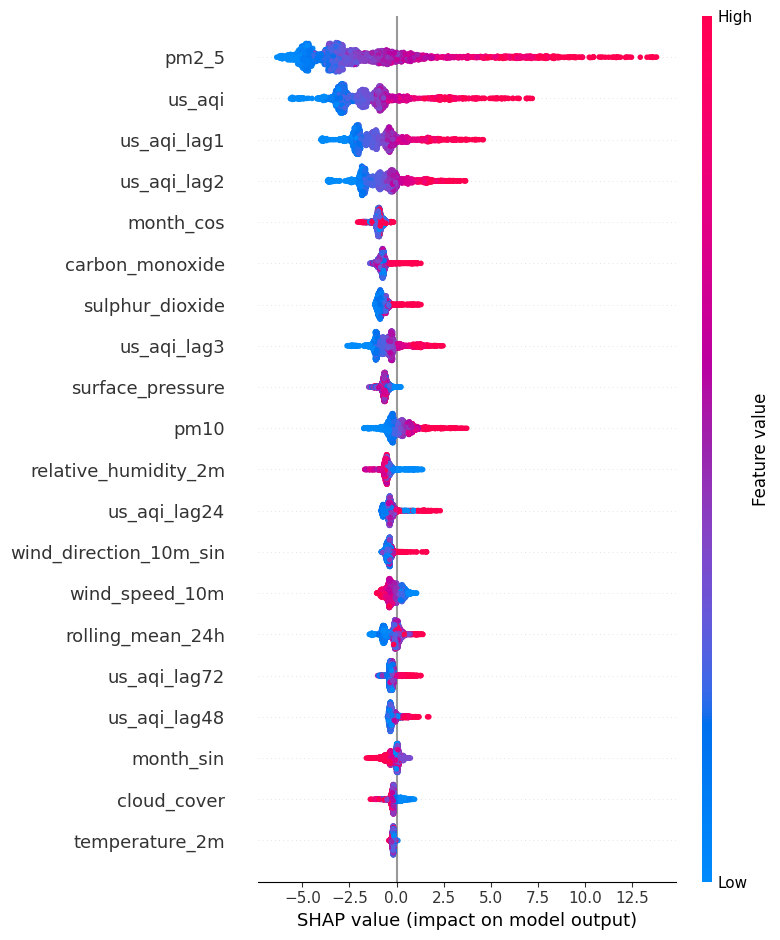


aqi_t+48h


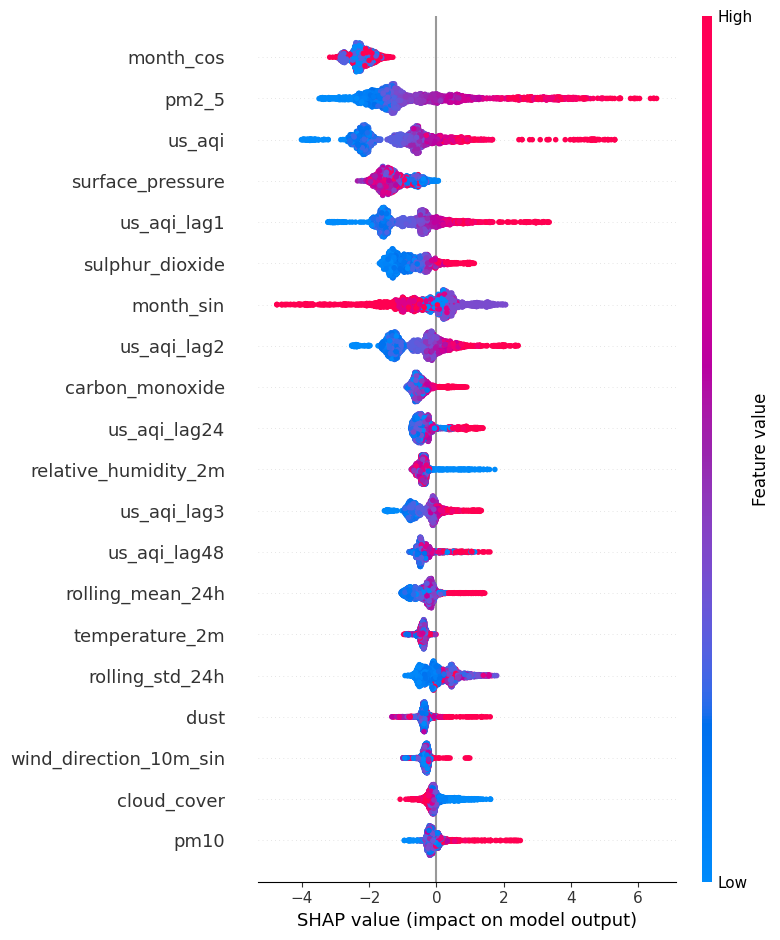


aqi_t+72h


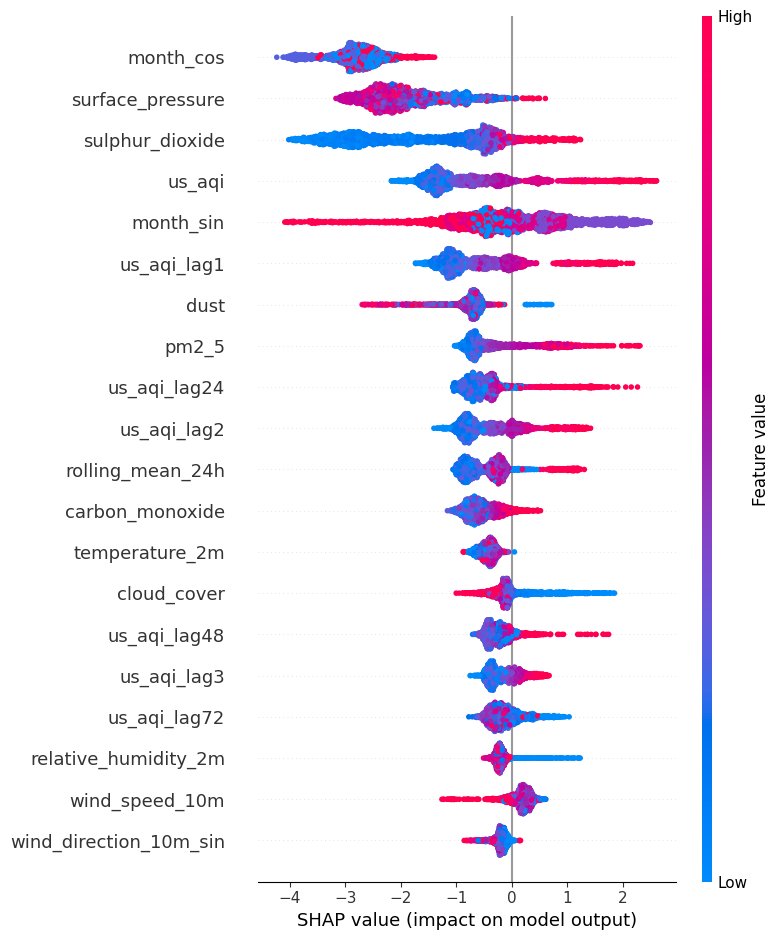

In [121]:
for horizon in horizons:
    print(f"\n{'='*50}\n{horizon}\n{'='*50}")
    shap.summary_plot(shap_values_dict[horizon], X_test_rf, show=True)

#### SHAP Findings

- t+24h: pm2_5 dominates SHAP importance, followed by us_aqi and its short lags (lag1-3),
  consistent with correlation and feature-importance findings; direction is intuitive (high pm2_5
  pushes predicted AQI up)
- t+48h: month_cos rises to the top feature, with pm2_5/us_aqi still relevant but less dominant
- t+72h: month_cos and month_sin are the top two features, ahead of us_aqi, surface_pressure, and
  sulphur_dioxide; pm2_5 falls to 8th place, a striking reversal from t+24h
- This progression reinforces the earlier concern: since val (Jan-Apr) and test (Apr-Aug) cover only
  partial, non-overlapping seasonal windows, month's rising SHAP importance at longer horizons may
  partly reflect the model using month as a proxy for time period/split membership rather than purely
  causal seasonal AQI patterns
- This is a genuine limitation of the current train/val/test split, not a flaw in RF or SHAP,
  future work should validate this with a split spanning full, overlapping years across all three
  sets to confirm whether month's importance holds up

### Saving the models to hopsworks model registry

In [143]:
!pip  install hopsworks["python"]

import os
import joblib
import hopsworks

api_key = userdata.get("HOPSWORKS_API_KEY")

project = hopsworks.login(
        project='PearlsAQI_Project',
        host="eu-west.cloud.hopsworks.ai",
        port=443,
        api_key_value=api_key,
)

mr = project.get_model_registry()
algos = ["ridge","rf"]
for algo in algos:
  if algo == "ridge":
      results = test_results
      models = ridge_models
  else:
      results = rf_test_results
      models = rf_models
  for horizon in horizons:
      model_dir = f"Saved_models/{algo}_{horizon.replace('+','_')}"
      os.makedirs(model_dir, exist_ok=True)

      joblib.dump(models[horizon], f"{model_dir}/model.pkl")
      if algo == "ridge":
          joblib.dump(scaler, f"{model_dir}/scaler.pkl")  # same scaler, bundled per model

      save_model = mr.python.create_model(
          name=f"aqi_{algo}_{horizon.replace('+', '_')}",
          metrics={"test_r2": results[horizon]["r2"],
                  "test_mae": results[horizon]["mae"],
                  "test_rmse": results[horizon]["rmse"]},
          description=f"{algo} — {horizon}. Includes bundled scaler.pkl for preprocessing."
      )
      save_model.save(model_dir)
      print(f"Registered: aqi_{algo}_{horizon.replace('+', '_')}")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.6/258.6 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 130.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━


Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/41138


  0%|          | 0/6 [00:00<?, ?it/s]

Moving model files from 'Saved_models/ridge_aqi_t_24h' to the model registry... This is the default behavior. Set keep_original_files=True to copy files instead.


Uploading /content/Saved_models/ridge_aqi_t_24h/model.pkl: 0.000%|          | 0/1511 elapsed<00:00 remaining<?

...

Model created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/41138/models/aqi_rf_aqi_t_48h/1
Registered: aqi_rf_aqi_t_48h


  0%|          | 0/6 [00:00<?, ?it/s]

Moving model files from 'Saved_models/rf_aqi_t_72h' to the model registry... This is the default behavior. Set keep_original_files=True to copy files instead.


Uploading /content/Saved_models/rf_aqi_t_72h/model.pkl: 0.000%|          | 0/7392257 elapsed<00:00 remaining<?

Model created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/41138/models/aqi_rf_aqi_t_72h/1
Registered: aqi_rf_aqi_t_72h


Note: aqi_rf_* model descriptions in the registry incorrectly mention a bundled scaler — RF models
do not require scaling; this is a metadata labeling error only and does not affect model behavior.

In [144]:
for horizon in horizons:
    model_dir = f"Saved_models/nn_{horizon.replace('+', '_')}"
    os.makedirs(model_dir, exist_ok=True)

    # Save the Keras model itself (SavedModel format, saves into model_dir/model.keras or a subfolder)
    nn_models[horizon].save(f"{model_dir}/model.keras")

    # Bundle the scaler — NN needs it just like Ridge
    joblib.dump(scaler, f"{model_dir}/scaler.pkl")

    save_model = mr.tensorflow.create_model(
        name=f"aqi_nn_{horizon.replace('+', '_')}",
        metrics={
            "test_r2": nn_test_results[horizon]["r2"],
            "test_mae": nn_test_results[horizon]["mae"],
            "test_rmse": nn_test_results[horizon]["rmse"]
        },
        description=f"Neural Network — {horizon}. Includes bundled scaler.pkl for preprocessing. Comparison model, not deployed."
    )

    save_model.save(model_dir)
    print(f"Registered: aqi_nn_{horizon.replace('+', '_')}")

  0%|          | 0/6 [00:00<?, ?it/s]

Moving model files from 'Saved_models/nn_aqi_t_24h' to the model registry... This is the default behavior. Set keep_original_files=True to copy files instead.


Uploading /content/Saved_models/nn_aqi_t_24h/model.keras: 0.000%|          | 0/209034 elapsed<00:00 remaining<…

Uploading /content/Saved_models/nn_aqi_t_24h/scaler.pkl: 0.000%|          | 0/1743 elapsed<00:00 remaining<?

Model created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/41138/models/aqi_nn_aqi_t_24h/1
Registered: aqi_nn_aqi_t_24h


...

  0%|          | 0/6 [00:00<?, ?it/s]

Moving model files from 'Saved_models/nn_aqi_t_72h' to the model registry... This is the default behavior. Set keep_original_files=True to copy files instead.


Uploading /content/Saved_models/nn_aqi_t_72h/model.keras: 0.000%|          | 0/209034 elapsed<00:00 remaining<…

Uploading /content/Saved_models/nn_aqi_t_72h/scaler.pkl: 0.000%|          | 0/1743 elapsed<00:00 remaining<?

Model created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/41138/models/aqi_nn_aqi_t_72h/1
Registered: aqi_nn_aqi_t_72h
